# SAG-PIML: State-Adaptive Gradient Physics-Informed Machine Learning
Steel Strand Total Load Prediction — Physics-Informed LightGBM Framework

In [1]:
# ====================
# Section 1: Import Libraries
# ====================
import os, sys, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, MultipleLocator
from matplotlib.patches import FancyArrowPatch
from collections import OrderedDict
from scipy.signal import savgol_filter
from scipy.ndimage import uniform_filter1d
from scipy.spatial import distance

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation, record_evaluation

import shap
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)
from matplotlib import font_manager, rcParams
from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Global Color Palette ────────────────────────────────────────────────────
C_ML      = '#E07B7B'   # red      ML (MSE/MAE)
C_PIML    = '#70B89A'   # green    Traditional PIML
C_SAG     = '#6C85F9'   # blue     SAG-PIML (main model)
C_TRUE    = '#2C2C2C'   # black    Measured/Record Data
FS        = 16           # Global font size

C:\Users\Lenovo\AppData\Roaming\Python\Python39\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# ====================
# Section 2: Global Settings
# ====================
random_seed = 42
np.random.seed(random_seed)

font_path = 'times+simsun.ttf'
if os.path.exists(font_path):
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = prop.get_name()
rcParams['axes.unicode_minus'] = False

FONTSIZE = 20
plt.rcParams.update({'font.size': FONTSIZE})

In [3]:
# ====================
# Section 3: Feature Column Definitions
# ====================
ori_col = [
    '1#height_winch(mm)', 'segment_counter', 'excavation_layer_counter', 'main_drive_outer_seal_grease_pressure(bar)',
    '1#locating_pin_cylinder_stroke(mm)', '2#locating_pin_cylinder_stroke(mm)', '3#locating_pin_cylinder_stroke(mm)',
    '1#arm_swing_cylinder_rodless_pressure(bar)', '1#arm_swing_cylinder_rod_pressure(bar)', '1#arm_swing_cylinder_stroke(mm)',
    '1#arm_extend_cylinder_rodless_pressure(bar)', '1#arm_extend_cylinder_rod_pressure(bar)', '1#arm_extend_cylinder_stroke(mm)',
    '1#arm_anti_twist_cylinder_inlet_pressure(bar)', '1#arm_upper_anti_twist_cylinder_1_2_pressure(bar)', '1#arm_upper_anti_twist_cylinder_3_4_pressure(bar)',
    '1#arm_lower_anti_twist_cylinder_5_6_pressure(bar)', '1#arm_lower_anti_twist_cylinder_7_8_pressure(bar)',
    'slurry_inlet_flow(m3/h)', 'slurry_outlet_flow(m3/h)', 'slurry_pump_P1.1_inlet_pressure(bar)', 'slurry_pump_P1.1_outlet_pressure(bar)',
    '1#pipe_rack_motor_lift_pressure(bar)', '1#pipe_rack_motor_release_pressure(bar)', '1#pipe_rack_torque(kNm)',
    'slurry_discharge_pipe_pressure(bar)', 'mud_pressure(bar)', '1#drum_1#motor_bearing_temp(degC)', 'hydraulic_oil_tank_temp(degC)',
    'propulsion_pump_pressure(bar)', 'cutting_arm_forward_pressure(bar)', 'cutting_arm_reverse_pressure(bar)',
    'slewing_bearing_outer_seal_grease_flow(ml/min)', 'drum_drive_grease_flow(ml/min)', '1#drum_speed(r/min)',
    'cutting_arm_rotation_angle(deg)', 'cutting_arm_rotation_speed(rpm)', '1#arm_current_excavation_radius(mm)',
    '1#arm_zone', '2#arm_zone',
    '1#drum_1#motor_current(A)', '1#drum_1#motor_torque(Nm)', '1#drum_1#motor_speed(rpm)', '1#drum_1#motor_temp(degC)',
    '1#drum_2#motor_current(A)', '1#drum_2#motor_torque(Nm)', '1#drum_2#motor_speed(rpm)', '1#drum_2#motor_temp(degC)',
    '1#arm_P2.1_speed(rpm)', '1#arm_P2.1_torque(Nm)', '1#arm_P2.1_current(A)',
    'P1.1_speed(rpm)', 'P1.1_torque(Nm)', 'P1.1_current(A)', '1#drum_torque(kNm)',
    'flush_slurry_flow(m3/h)', 'flush_pump_P0.1_inlet_pressure(bar)', 'flush_pump_P0.1_outlet_pressure(bar)',
    'P0.1_speed(rpm)', 'P0.1_torque(Nm)', 'P0.1_current(A)', '1#pipe_rack_lowering_length(mm)',
    'lift_sys_1#top_stroke(mm)', 'lift_sys_1#top_rodless_pressure(bar)', 'lift_sys_1#top_rod_pressure(bar)', 'lift_sys_1#top_lowering_depth(mm)',
    'lift_sys_2#top_stroke(mm)', 'lift_sys_2#top_rodless_pressure(bar)', 'lift_sys_2#top_rod_pressure(bar)', 'lift_sys_2#top_lowering_depth(mm)',
    'lift_sys_3#top_stroke(mm)', 'lift_sys_3#top_rodless_pressure(bar)', 'lift_sys_3#top_rod_pressure(bar)', 'lift_sys_3#top_lowering_depth(mm)',
    'lift_sys_4#top_stroke(mm)', 'lift_sys_4#top_rodless_pressure(bar)', 'lift_sys_4#top_rod_pressure(bar)', 'lift_sys_4#top_lowering_depth(mm)',
    'lift_sys_5#top_lowering_depth(mm)', 'lift_sys_6#top_lowering_depth(mm)', 'lift_sys_7#top_lowering_depth(mm)', 'lift_sys_8#top_lowering_depth(mm)',
    'device_excavated_depth(m)', 'steel_strand_total_load(kN)', 'hydraulic_oil_tank_level(mm)', 'hydraulic_oil_tank_humidity(%)',
    'pin_cylinder_rodless_pressure(bar)', 'pin_cylinder_rod_pressure(bar)', '1#arm_swing_cylinder_stroke2(mm)',
    '1#weight_winch(kg)', '1#speed_winch(Hz)', '2#weight_winch(kg)', '2#speed_winch(Hz)',
    '2#height_winch(mm)', '3#weight_winch(kg)', '3#speed_winch(Hz)', '3#height_winch(mm)',
    'total_weight_winch(kg)', 'absolute_tilt_angle(deg)', 'buoyancy(kN)', 'gravity(kN)', 'assumed_lateral_resistance(kN)',
    'strand_load_rate_of_change', 'depth(m)',
]
TARGET_FEATURE = 'steel_strand_total_load(kN)'

In [4]:
# ====================
# Section 4: Data Loading and Preprocessing
# ====================
def load_and_preprocess(filepath='data_vsm.csv'):
    data = pd.read_csv(filepath)[ori_col]
    data.replace([np.inf, -np.inf], np.nan, inplace=True)

    for i in range(1, len(data)):
        if data.iloc[i]['gravity(kN)'] < data.iloc[i - 1]['gravity(kN)']:
            data.iloc[i, data.columns.get_loc('gravity(kN)')] = data.iloc[i - 1]['gravity(kN)']

    data[f'{TARGET_FEATURE}_shift'] = data[TARGET_FEATURE].shift(5)
    data.dropna(subset=[f'{TARGET_FEATURE}_shift'], inplace=True)
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.fillna(0, inplace=True)
    return data

In [5]:
# ====================
# Section 5: Physics Model
# ====================
def assign_soil_params(depth):
    boundaries     = [0, -2.72, -6.72, -10.22, -17.22, -20.52, -float('inf')]
    c_values       = [20, 18, 11.1, 13.8, 47.4, 3.6]
    fai_values     = [18, 24,  3.7, 13.5, 16.4, 30.6]
    pressure_coeff = [0.5, 0.48, 0.62, 0.57, 0.28, 0.48]
    unit_weight    = [18.8, 18.6, 17.4, 17.4,  9.7, 18.4]
    for i in range(len(boundaries) - 1):
        if boundaries[i + 1] < depth <= boundaries[i]:
            return c_values[i], fai_values[i], pressure_coeff[i], unit_weight[i]
    return None, None, None, None


def add_soil_features(data):
    data[['cohesion_c(kPa)', 'friction_angle(deg)', 'lateral_pressure_coeff', 'unit_weight']] = (
        data['depth(m)'].apply(lambda x: pd.Series(assign_soil_params(x)))
    )
    return data


def calculate_passive_soil_pressure(data, alpha=0.004):
    data['Kp'] = np.tan(np.radians(45 + data['friction_angle(deg)'] / 2)) ** 2
    data['tilt_induced_resistance(kN)'] = (
        4 * math.pi * (
            0.5 * data['Kp'] * data['unit_weight'] * data['depth(m)'] ** 2
            + 2 * data['cohesion_c(kPa)'] * np.sqrt(data['Kp']) * (-data['depth(m)'])
            - 10 * (-data['depth(m)'])
        ) * alpha
    )
    return data


def calculate_physical_loss(gravity, depth, resistance, alpha, beta=0.3, K0=0.5, h=3):
    return gravity - (1 + beta) * (10.556 * 100 * (20 + alpha * depth) * K0 * (depth - h)) / 100 - resistance


def add_theoretical_forces(data, alpha=0.3, beta=0.2, K0=0.5, h=4, fi=0.8):
    resistance = tf.convert_to_tensor(data['tilt_induced_resistance(kN)'], dtype=tf.float32)
    depth      = tf.convert_to_tensor(-data['depth(m)'],           dtype=tf.float32)
    gravity    = tf.convert_to_tensor(data['gravity(kN)'],           dtype=tf.float32)
    data['theoretical_suspension_force(kN)']          = calculate_physical_loss(gravity, depth, resistance, alpha, beta, K0, h)
    data['theoretical_suspension_force_sinking(kN)'] = data['theoretical_suspension_force(kN)'] - (-data['depth(m)'] * 1 * 16.8 * math.pi * fi)
    data['theoretical_suspension_force_lifting(kN)'] = data['theoretical_suspension_force(kN)'] -  (data['depth(m)']  * 1 * 16.8 * math.pi * fi)
    return data

In [6]:
# ====================
# Section 6: Feature Engineering (SHAP Selection)
# ====================
def select_features_by_shap(data, target_feature, drop_cols=None, top_n=12):
    if drop_cols is None:
        drop_cols = [
            'lift_sys_3#top_rodless_pressure(bar)', 'lift_sys_2#top_rodless_pressure(bar)',
            'lift_sys_4#top_rodless_pressure(bar)', 'lift_sys_1#top_rodless_pressure(bar)',
        ]
    y = data[target_feature].values.reshape(-1, 1)
    X = data.drop([target_feature] + drop_cols, axis=1)
    scaler   = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, shuffle=True)
    X_train_df = pd.DataFrame(X_train, columns=X.columns)

    params = {'objective': 'regression', 'metric': 'l1', 'boosting_type': 'gbdt'}
    bst = lgb.train(params, lgb.Dataset(X_train_df, label=y_train), num_boost_round=100)

    explainer   = shap.TreeExplainer(bst)
    shap_values = explainer.shap_values(X_train_df)
    importance  = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
    top_features  = importance_df.nlargest(top_n, 'Importance')['Feature'].tolist()
    shap.summary_plot(shap_values, X_train_df, plot_type='violin',
                      max_display=top_n, feature_names=X_train_df.columns)
    return top_features


def build_feature_set(data, top_shap_features):
    fixed = []
    return fixed + top_shap_features

In [7]:
# ====================
# Section 7: Custom Loss Functions
# ====================

class UncertaintyWeightedPIML:
    """
    Uncertainty-weighted PIML（Kendall & Gal, NeurIPS 2017）。

    Loss = w_data * e_data² + w_phy * e_phy²
    where w_data = 1/(2σ̃₁²), w_phy = 1/(2σ̃₂²)
    σ̃ is the normalized relative uncertainty (σ_i / σ_total),
    ensuring gradient magnitude is consistent with data MSE while reflecting the uncertainty difference between the two tasks.
    """
    def __init__(self, gravity, depth, resistance=None,
                 alpha=0.3, beta=0.2, h=4, K0=0.5, eps=1e-6):
        self.gravity    = np.array(gravity.numpy()    if hasattr(gravity,    'numpy') else gravity)
        self.depth      = np.array(depth.numpy()      if hasattr(depth,      'numpy') else depth)
        self.resistance = np.array(resistance.numpy() if (resistance is not None and hasattr(resistance, 'numpy'))
                          else (resistance if resistance is not None else np.zeros_like(self.gravity)))
        self.alpha, self.beta, self.h, self.K0 = alpha, beta, h, K0
        self.eps        = eps
        self.w_data     = 1.0   # updated after set_sigmas
        self.w_phy      = 1.0   # updated after set_sigmas
        self.train_indices = None
        self.test_indices  = None

    def set_sigmas(self, y_train, train_orig_idx):
        """
        Called once before training to estimate the relative uncertainty of both tasks.
        σ₁ = std(y_train)              → data noise
        σ₂ = std(y_train - y_phy)      → physics residual noise
        Weight normalization: w_i = (σ_total / σ_i)², keeping w_data + w_phy at scale 2.
        """
        y_phy = np.array(self.calculate_theoretical_force(train_orig_idx)).flatten()
        s1    = float(np.std(y_train)           + self.eps)
        s2    = float(np.std(y_train - y_phy)   + self.eps)
        s_tot = (s1 + s2) / 2.0   # reference magnitude
        # w_i = (s_tot / s_i)^2; larger s_i (more noise) → smaller weight
        self.w_data = (s_tot / s1) ** 2
        self.w_phy  = (s_tot / s2) ** 2
        print(f"[UW-PIML] s_data={s1:.1f}  s_phy={s2:.1f}  "
              f"w_data={self.w_data:.4f}  w_phy={self.w_phy:.4f}")

    @property
    def lambda_phy(self):
        """Effective physics weight ratio, for metric display"""
        return self.w_phy / (self.w_data + self.eps)

    def calculate_theoretical_force(self, indices=None):
        g = self.gravity[indices]    if indices is not None else self.gravity
        d = self.depth[indices]      if indices is not None else self.depth
        r = self.resistance[indices] if indices is not None else self.resistance
        return calculate_physical_loss(g, d, r, self.alpha, self.beta, self.K0, self.h)

    def __call__(self, preds, train_data):
        y_true = train_data.get_label()
        idx    = self.train_indices[:len(preds)] if self.train_indices is not None else None
        theoretical_force = np.array(self.calculate_theoretical_force(idx)).flatten()

        e_data = preds - y_true
        e_phy  = preds - theoretical_force

        # grad = 2*w_data*e_data + 2*w_phy*e_phy
        grad = 2.0 * self.w_data * e_data + 2.0 * self.w_phy * e_phy
        hess = 2.0 * (self.w_data + self.w_phy) * np.ones_like(y_true)
        return grad, hess
class HuberPhyLossObjective:
    """
    SAG-PIML — State-Adaptive Gradient physics-informed loss.
    Aligned with reference implementation:
      - g(e): exponent clip(-100,0), strictly g(e)∈[0,1), no negative values
      - Theoretical force: full computation then truncate [:len(preds)] to always align
      - hess: uniformly set to 2 (consistent with reference code)
    """
    def __init__(self, gravity, depth, resistance,
                 delta=1600, alpha=0.3, beta=0.2, h=4, K0=0.5, k=0.75):
        self.gravity    = np.array(gravity.numpy()    if hasattr(gravity,    'numpy') else gravity)
        self.depth      = np.array(depth.numpy()      if hasattr(depth,      'numpy') else depth)
        self.resistance = np.array(resistance.numpy() if hasattr(resistance, 'numpy') else resistance)
        self.alpha, self.beta, self.h, self.K0 = alpha, beta, h, K0
        self.delta         = delta
        self.k             = k
        self.train_indices = None
        self.test_indices  = None

    def calculate_theoretical_force(self):
        """Full computation; caller truncates [:n] as needed."""
        return calculate_physical_loss(
            self.gravity, self.depth, self.resistance,
            self.alpha, self.beta, self.K0, self.h)

    def g(self, theoretical_force, y_true):
        """
        Soft gating: normal region=0, anomaly region smoothly tends to 1, strictly g(e)∈[0,1).
        exponent clipped to (-100,0) ensures non-positive, exp(exponent)∈(0,1], no negative g(e).
        """
        theoretical_force = tf.reshape(tf.cast(theoretical_force, tf.float32), [-1])
        y_true            = tf.reshape(tf.cast(y_true,            tf.float32), [-1])
        abs_diff = tf.abs(theoretical_force - y_true)
        exponent = -self.k * (abs_diff - self.delta) / 20
        exponent = tf.clip_by_value(exponent, -100, 0)
        return tf.where(abs_diff < self.delta,
                        0.0,
                        2.0 / (1.0 + tf.exp(exponent)) - 1.0)

    def __call__(self, preds, train_data):
        y_true            = train_data.get_label()
        theoretical_force = np.array(self.calculate_theoretical_force()).flatten()[:len(preds)]

        e_data    = y_true - preds
        e_phy     = theoretical_force - preds
        calc_loss = y_true - theoretical_force
        g_e       = np.array(self.g(theoretical_force, y_true)).flatten()

        is_anomaly   = np.abs(calc_loss) > self.delta
        grad_normal  = -e_data
        grad_anomaly = -(g_e * e_phy + (1.0 - g_e) * e_data)

        grad = np.where(is_anomaly, grad_anomaly, grad_normal)
        hess = np.ones_like(y_true)
        return grad, hess


# ── ML Loss Function Switch ──────────────────────────────────────────────────────
# Change ML_LOSS_TYPE to switch loss; no other code changes needed.
# 'huber' : Huber Loss (original default, balances MSE and MAE, delta = 1.5×y_train.std)
# 'mse'   : Mean Squared Error (L2, suitable when distribution is concentrated with few outliers)
# 'mae'   : Mean Absolute Error (L1, suitable for large-scale data or many outliers)
ML_LOSS_TYPE = 'mse'  # ← Switch here: 'huber' | 'mse' | 'mae'


class MSELossObjective:
    """
    Standard MSE Loss for ML-MSE training.
    init_score=y_mean mechanism: prediction excludes init_score, must manually add y_mean.
    """
    def __init__(self):
        self.y_mean = 0.0

    def set_y_mean(self, y_mean):
        self.y_mean = float(y_mean)

    def get_init_score(self, n):
        return np.full(n, self.y_mean)

    def __call__(self, preds, train_data):
        y_true = train_data.get_label()
        grad = preds - y_true
        hess = np.ones_like(y_true)
        return grad, hess

    def feval(self, preds, train_data):
        y_true = train_data.get_label()
        loss   = 0.5 * (y_true - preds) ** 2
        y_mean = np.mean(np.abs(y_true)) + 1e-8
        return 'custom_loss', float(np.sqrt(np.mean(loss)) / y_mean), False

    def predict(self, model, X):
        """prediction excludes init_score; add y_mean back to get real predicted values"""
        return model.predict(X) + self.y_mean


class MAELossObjective:
    """
    Standard MAE Loss (L1) for ML-MAE training.
    init_score=y_mean mechanism: prediction excludes init_score, must manually add y_mean.
    Note: MAE uses hess=1 (pseudo-Hessian), which is the standard LightGBM approach.
    """
    def __init__(self):
        self.y_mean = 0.0

    def set_y_mean(self, y_mean):
        self.y_mean = float(y_mean)

    def get_init_score(self, n):
        return np.full(n, self.y_mean)

    def __call__(self, preds, train_data):
        y_true = train_data.get_label()
        r      = y_true - preds
        grad   = -np.sign(r)          # MAE gradient
        hess   = np.ones_like(y_true) # pseudo-Hessian
        return grad, hess

    def feval(self, preds, train_data):
        y_true = train_data.get_label()
        loss   = np.abs(y_true - preds)
        y_mean = np.mean(np.abs(y_true)) + 1e-8
        return 'custom_loss', float(np.mean(loss) / y_mean), False

    def predict(self, model, X):
        """prediction excludes init_score; add y_mean back to get real predicted values"""
        return model.predict(X) + self.y_mean


class HuberLossObjective:
    """
    Standard Huber Loss for ML-Huber training (original default loss).
    init_score=y_mean mechanism: prediction excludes init_score, must manually add y_mean.
    HUBER_DELTA must be >= y.std() in magnitude, otherwise gradient cancellation in leaves causes non-convergence.
    """
    def __init__(self, delta=800.0):
        self.delta  = delta
        self.y_mean = 0.0

    def set_y_mean(self, y_mean):
        self.y_mean = float(y_mean)

    def get_init_score(self, n):
        return np.full(n, self.y_mean)

    def __call__(self, preds, train_data):
        y_true = train_data.get_label()
        r      = y_true - preds
        abs_r  = np.abs(r)
        grad = np.where(abs_r <= self.delta,
                        preds - y_true,
                        self.delta * np.sign(preds - y_true))
        hess = np.ones_like(r)
        return grad, hess

    def feval(self, preds, train_data):
        y_true = train_data.get_label()
        r      = y_true - preds
        abs_r  = np.abs(r)
        loss   = np.where(abs_r <= self.delta,
                          0.5 * r ** 2,
                          self.delta * (abs_r - 0.5 * self.delta))
        y_mean = np.mean(np.abs(y_true)) + 1e-8
        return 'custom_loss', float(np.sqrt(np.mean(loss)) / y_mean), False

    def predict(self, model, X):
        """prediction excludes init_score; add y_mean back to get real predicted values"""
        return model.predict(X) + self.y_mean

In [8]:
# ====================
# Section 8: Evaluation Functions
# ====================
def custom_metric_huberphy(preds, train_data, huber_phy_loss):
    y_true            = train_data.get_label()
    theoretical_force = np.array(huber_phy_loss.calculate_theoretical_force()).flatten()[:len(preds)]
    g_e               = np.array(huber_phy_loss.g(theoretical_force, y_true)).flatten()

    data_loss     = np.abs(y_true - preds)
    physical_loss = np.abs(theoretical_force - preds)
    total_loss    = g_e * physical_loss + (1.0 - g_e) * data_loss

    y_mean = np.mean(np.abs(y_true)) + 1e-8          # ← add this line
    return 'custom_loss', float(np.mean(total_loss) / y_mean), False   # ← divide by y_mean

def custom_metric_pinn(preds, train_data, fusion_loss):
    """Uncertainty-weighted PIML metric：NRMSE of combined loss"""
    y_true = train_data.get_label()
    n      = len(preds)
    ti = fusion_loss.test_indices
    if ti is not None and n == len(ti):
        theoretical_force = fusion_loss.calculate_theoretical_force(ti[:n])
    elif fusion_loss.train_indices is not None and n <= len(fusion_loss.train_indices):
        theoretical_force = fusion_loss.calculate_theoretical_force(
            fusion_loss.train_indices[:n])
    else:
        theoretical_force = fusion_loss.calculate_theoretical_force()[:n]

    theoretical_force = np.array(theoretical_force).flatten()
    e_data = preds - y_true
    e_phy  = preds - theoretical_force
    total_loss = fusion_loss.w_data * e_data**2 + fusion_loss.w_phy * e_phy**2
    y_mean = np.mean(np.abs(y_true)) + 1e-8
    return 'custom_loss', float(np.sqrt(np.mean(total_loss)) / y_mean), False

In [9]:
# ====================
# Section 9: Training Pipeline
# ====================
NUM_BOOST_ROUND = 5000
# HUBER_DELTA moved to Section 11 main pipeline, auto-configured based on ML_LOSS_TYPE

# ── ML-Huber Hyperparameters (filled by Bayesian optimization; defaults are reasonable) ──
BEST_ML_PARAMS = {
    'learning_rate'    : 0.025,
    'num_leaves'       : 41,
    'max_depth'        : 10,
    'min_data_in_leaf' : 50,
    'feature_fraction' : 1,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.01,
    'lambda_l2'        : 0.0020685651052978877,
    'min_gain_to_split': 0.0,
}
BEST_PIML_PARAMS = {
    'learning_rate'    : 0.025,
    'num_leaves'       : 64,
    'max_depth'        : 8,
    'min_data_in_leaf' : 50,
    'feature_fraction' : 1,
    'bagging_fraction' : 0.8, 
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.01,
    'lambda_l2'        : 0.005651162208887998,
    'min_gain_to_split': 0.0,
}

# ── SAG-PIML Hyperparameters (filled by Bayesian optimization) ────────────────────────
BEST_SAG_PARAMS = {
    'learning_rate'    : 0.002,
    'num_leaves'       : 50,
    'max_depth'        : 5,
    'min_data_in_leaf' : 50,
    'feature_fraction' : 1,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 10,
    'lambda_l1'        : 0.01,
    'lambda_l2'        : 0.0005,
    'min_gain_to_split': 0.0,
}


def build_params(objective, model_type):
    if model_type == 'ml':
        base = {**BEST_ML_PARAMS, 'boosting_type': 'gbdt', 'verbosity': -1}
        return {**base, 'objective': huber_loss_obj, 'metric': 'None'}
    elif model_type == 'fusion':                                    # ← newly added
        base = {**BEST_PIML_PARAMS, 'boosting_type': 'gbdt', 'verbosity': -1}
        return {**base, 'objective': objective, 'metric': 'None'}
    else:  # huberphy
        base = {**BEST_SAG_PARAMS, 'boosting_type': 'gbdt', 'verbosity': -1}
        return {**base, 'objective': objective, 'metric': 'None'}

class TqdmProgressCallback:
    def __init__(self, num_boost_round, fold, n_splits, model_type):
        self.pbar = tqdm(total=num_boost_round,
                         desc=f"{model_type} | fold {fold}/{n_splits}",
                         unit='round', leave=False)
        self.best_val = float('inf')

    def __call__(self, env):
        for name, metric, val, _ in env.evaluation_result_list:
            if 'valid' in name:
                self.best_val = min(self.best_val, val)
        self.pbar.set_postfix(val_loss=f'{self.best_val:.4f}')
        self.pbar.update(1)

    def close(self):
        self.pbar.close()
        if self.best_val < float('inf'):
            tqdm.write(f"  └─ best_val={self.best_val:.4f}")


def train_and_predict(X_train_fold, X_test_ori, y_train_fold, y_test_target,
                      params, model_type, feval_fn,
                      num_boost_round=NUM_BOOST_ROUND, fold=1, n_splits=5):
    if model_type == 'ml':
        # Custom Huber requires init_score=y_mean; add y_mean back after predict
        n_tr  = len(y_train_fold)
        n_val = len(y_test_target)
        train_data = lgb.Dataset(X_train_fold, y_train_fold,
                                 init_score=huber_loss_obj.get_init_score(n_tr))
        valid_data = lgb.Dataset(X_test_ori[:n_val], y_test_target,
                                 init_score=huber_loss_obj.get_init_score(n_val),
                                 reference=train_data)
        feval_fn = huber_loss_obj.feval
    else:
        train_data = lgb.Dataset(X_train_fold, y_train_fold)
        valid_data = lgb.Dataset(X_test_ori[:len(y_test_target)], y_test_target,
                                 reference=train_data)

    evals_result = {}
    progress_cb  = TqdmProgressCallback(num_boost_round, fold, n_splits, model_type)
    callbacks    = [record_evaluation(evals_result), progress_cb]
    feval_kw     = {'feval': feval_fn} if feval_fn is not None else {}

    _devnull = open(os.devnull, 'w')
    _old_out, _old_err = sys.stdout, sys.stderr
    sys.stdout, sys.stderr = _devnull, _devnull
    try:
        model = lgb.train(
            {**params, 'verbosity': -1}, train_data,
            valid_sets=[train_data, valid_data],
            num_boost_round=num_boost_round,
            callbacks=callbacks,
            **feval_kw,
        )
    finally:
        sys.stdout, sys.stderr = _old_out, _old_err
        _devnull.close()

    progress_cb.close()

    # ── Best round refit: find the round with lowest valid loss and predict with that round ──
    valid_key  = 'custom_loss'
    valid_hist = evals_result.get('valid_1', {}).get(valid_key, [])
    if len(valid_hist) > 0:
        best_round = int(np.argmin(valid_hist)) + 1   # 1-based
    else:
        best_round = model.num_trees()
    # model.predict supports num_iteration parameter, truncated to best_round trees
    tqdm.write(f"  └─ best_round={best_round}/{model.num_trees()}")
    if model_type == 'ml':
        # ML uses init_score offset; y_mean must be added regardless of truncation
        return (model.predict(X_test_ori,   num_iteration=best_round) + huber_loss_obj.y_mean,
                model.predict(X_train_fold, num_iteration=best_round) + huber_loss_obj.y_mean,
                model, evals_result)
    return (model.predict(X_test_ori,   num_iteration=best_round),
            model.predict(X_train_fold, num_iteration=best_round),
            model, evals_result)


def run_kfold_training(X_train_shuffled, train_orig_idx,
                       y_train_target, X_test_ori, y_test_target,
                       params, model_type, feval_fn,
                       loss_obj=None, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    all_train_losses, all_valid_losses, val_mse_list = [], [], []
    model_final = None

    fold_pbar = tqdm(total=n_splits, desc=f'{model_type} CV folds', unit='fold')
    for fold, (train_idx, _) in enumerate(kf.split(X_train_shuffled), start=1):
        X_fold   = X_train_shuffled[train_idx]
        y_fold   = y_train_target[train_idx]
        orig_idx = train_orig_idx[train_idx]

        if loss_obj is not None:
            loss_obj.train_indices = orig_idx

        y_test_pred, _, model, evals = train_and_predict(
            X_fold, X_test_ori, y_fold, y_test_target,
            params, model_type, feval_fn, fold=fold, n_splits=n_splits,
        )
        mse = mean_squared_error(y_test_target, y_test_pred[:len(y_test_target)])
        val_mse_list.append(mse)

        train_key, valid_key = 'custom_loss', 'custom_loss'

        all_train_losses.append(evals.get('training', {}).get(train_key, []))
        all_valid_losses.append(evals.get('valid_1',  {}).get(valid_key, []))
        model_final = model

        fold_pbar.set_postfix(mse=f'{mse:.4f}')
        fold_pbar.update(1)

    fold_pbar.close()
    tqdm.write(f"[{model_type}] Average validation MSE: {np.mean(val_mse_list):.4f}")
    return model_final, all_train_losses, all_valid_losses

In [10]:
# ====================
# Section 10: Data Preparation (Feature Scaling & Splitting)
# ====================
SKIP_ROWS = 0

def prepare_data(data, top_features, test_ratio=0.2, test_size=4800):
    data_use     = data.iloc[SKIP_ROWS:].reset_index(drop=False)
    orig_row_idx = data_use['index'].values
    data_use     = data_use.drop(columns=['index'])

    y_data   = data_use[[TARGET_FEATURE]]
    X_data   = data_use.drop(columns=[TARGET_FEATURE], errors='ignore')

    scaler   = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_data[top_features])

    n_total = len(X_scaled)
    n_test  = int(n_total * test_ratio)
    n_train = n_total - n_test

    X_train0   = X_scaled[:n_train]
    X_test_ori = X_scaled[n_train:]
    y_train0   = y_data.values[:n_train]
    y_test_ori = y_data.values[n_train:]

    shuffle_idx      = np.random.permutation(n_train)
    X_train_shuffled = X_train0[shuffle_idx]
    y_train_shuffled = y_train0[shuffle_idx]
    train_orig_idx   = orig_row_idx[:n_train][shuffle_idx]

    y_train_target = y_train_shuffled[:, 0]
    y_test_target  = y_test_ori[:test_size, 0]

    print(f"Skipping first {SKIP_ROWS} rows, using rows {SKIP_ROWS}~{SKIP_ROWS+n_total-1} (total {n_total:,})")
    print(f"Train set: {n_train:,} rows  Test set: {n_test:,} rows (validation truncated to {test_size:,} rows)")

    return (X_train_shuffled, y_train_shuffled,
            X_test_ori[:test_size], y_test_ori[:test_size],
            X_test_ori, y_test_ori,
            y_train_target, y_test_target,
            train_orig_idx)

C:\Users\Lenovo\AppData\Roaming\Python\Python39\site-packages\lightgbm\basic.py:300: UserWarning: Converting column-vector to 1d array
  _log_warning('Converting column-vector to 1d array')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25072
[LightGBM] [Info] Number of data points in the train set: 29692, number of used features: 109
[LightGBM] [Info] Start training from score 1460.943569


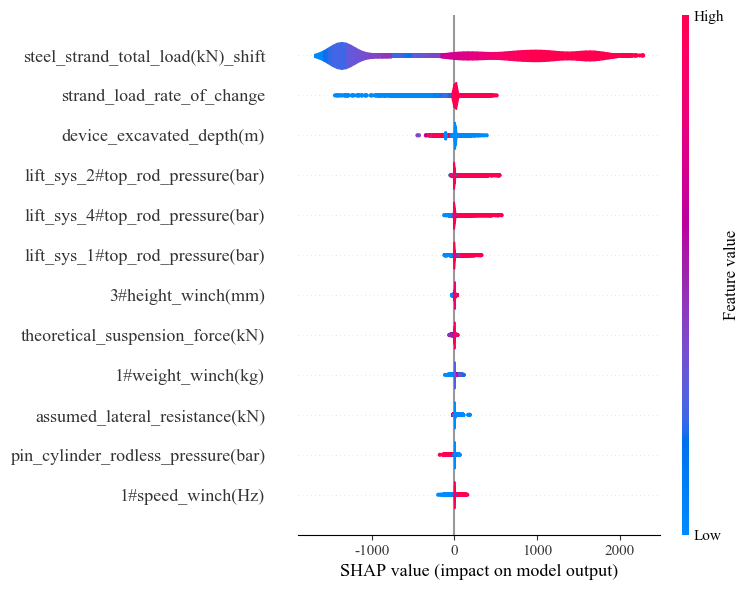

Skipping first 0 rows, using rows 0~37114 (total 37,115)
Train set: 29,692 rows  Test set: 7,423 rows (validation truncated to 4,800 rows)
[UW-PIML] s_data=1256.0  s_phy=1000.0  w_data=0.8066  w_phy=1.2724
[ML] Using MSE (L2) loss  | y_train.std=1256.01 kN
     y_mean = 1495.08 kN


In [11]:
# ====================
# Section 11: Main Pipeline
# ====================
data = load_and_preprocess('data_vsm.csv')
data = add_soil_features(data)
data = calculate_passive_soil_pressure(data, alpha=0.004)
data = add_theoretical_forces(data, alpha=0.3, beta=0.2, K0=0.5, h=4)

top_shap     = select_features_by_shap(data, TARGET_FEATURE)
top_features = build_feature_set(data, top_shap)

(X_train_shuffled, y_train_shuffled,
 X_test, y_test,
 X_test_ori, y_test_ori,
 y_train_target, y_test_target,
 train_orig_idx) = prepare_data(data, top_features)

# ── Physics tensors (full array, precisely indexed by train_orig_idx) ──────────
depth_tensor      = tf.convert_to_tensor(-data['depth(m)'],           dtype=tf.float32)
gravity_tensor    = tf.convert_to_tensor(data['gravity(kN)'],           dtype=tf.float32)
resistance_tensor = tf.convert_to_tensor(data['tilt_induced_resistance(kN)'], dtype=tf.float32)

fusion_loss    = UncertaintyWeightedPIML(gravity_tensor, depth_tensor, resistance_tensor)
huber_phy_loss = HuberPhyLossObjective(gravity_tensor, depth_tensor, resistance_tensor,
                                        delta=1600, k=1)

# Test set row indices (used by metric)
n_use_        = len(data) - SKIP_ROWS
n_test_       = int(n_use_ * 0.2)
test_indices_ = np.arange(SKIP_ROWS + (n_use_ - n_test_), SKIP_ROWS + n_use_)
fusion_loss.test_indices    = test_indices_
huber_phy_loss.test_indices = test_indices_

# UW-PIML: estimate σ₁², σ₂² from training set (called once before training)
fusion_loss.set_sigmas(y_train_target, train_orig_idx)

feval_piml = lambda p, d: custom_metric_pinn(p, d, fusion_loss)
feval_sag  = lambda p, d: custom_metric_huberphy(p, d, huber_phy_loss)

# ── ML loss function initialization (controlled by ML_LOSS_TYPE switch) ─────────
# Switch loss: only modify ML_LOSS_TYPE = 'huber' | 'mse' | 'mae' at top of Section 7
if ML_LOSS_TYPE == 'mae':
    huber_loss_obj = MAELossObjective()
    print(f'[ML] Using MAE (L1) loss  | y_train.std={np.std(y_train_target):.2f} kN')
elif ML_LOSS_TYPE == 'mse':
    huber_loss_obj = MSELossObjective()
    print(f'[ML] Using MSE (L2) loss  | y_train.std={np.std(y_train_target):.2f} kN')
else:  # default 'huber'
    HUBER_DELTA    = float(np.std(y_train_target)) * 1.5
    huber_loss_obj = HuberLossObjective(delta=HUBER_DELTA)
    print(f'[ML] Using Huber loss  delta={HUBER_DELTA:.2f} kN  (1.5*std={np.std(y_train_target):.2f})')
huber_loss_obj.set_y_mean(float(np.mean(y_train_target)))
print(f'     y_mean = {np.mean(y_train_target):.2f} kN')

In [12]:
# # ====================
# # Section 12: Bayesian Hyperparameter Optimization
# # ====================
# # Note: After the first run, fill the best parameters into BEST_ML_PARAMS / BEST_SAG_PARAMS in Cell 9,
# #       then comment out this entire cell to skip optimization and reuse existing parameters.
# # ====================

# N_TRIALS_BAYES     = 50
# BAYES_BOOST_ROUNDS = 5000   # consistent with full training

# def _split_sub():
#     n_total   = len(X_train_shuffled)
#     n_sub_val = int(n_total * 0.2)
#     return (
#         X_train_shuffled[n_sub_val:],  y_train_target[n_sub_val:],
#         X_train_shuffled[:n_sub_val],  y_train_target[:n_sub_val],
#         train_orig_idx[n_sub_val:],    train_orig_idx[:n_sub_val],
#     )

# def _silent_train(params, X_tr, y_tr, X_val, y_val, feval=None):
#     dtrain = lgb.Dataset(X_tr,  label=y_tr)
#     dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
#     _devnull = open(os.devnull, 'w')
#     _old_out, _old_err = sys.stdout, sys.stderr
#     sys.stdout, sys.stderr = _devnull, _devnull
#     try:
#         kw    = {'feval': feval} if feval else {}
#         model = lgb.train(params, dtrain,
#                           num_boost_round=BAYES_BOOST_ROUNDS,
#                           valid_sets=[dval],
#                           callbacks=[lgb.record_evaluation({})], **kw)
#     finally:
#         sys.stdout, sys.stderr = _old_out, _old_err
#         _devnull.close()
#     return model

# def _silent_train_dataset(params, dtrain, dval, feval=None):
#     _devnull = open(os.devnull, 'w')
#     _old_out, _old_err = sys.stdout, sys.stderr
#     sys.stdout, sys.stderr = _devnull, _devnull
#     try:
#         kw    = {'feval': feval} if feval else {}
#         model = lgb.train(params, dtrain,
#                           num_boost_round=BAYES_BOOST_ROUNDS,
#                           valid_sets=[dval],
#                           callbacks=[lgb.record_evaluation({})], **kw)
#     finally:
#         sys.stdout, sys.stderr = _old_out, _old_err
#         _devnull.close()
#     return model


# # ── BO sweeps these 4 parameters (for plotting) + lambda_l2 regularization ───────
# # learning_rate / num_leaves / max_depth / lambda_l2
# # Other parameters fixed at reasonable defaults

# # ── ML (Huber/MSE/MAE) Bayesian objective function ──────────────────────────────
# def _bayes_objective_ml(trial):
#     if ML_LOSS_TYPE == 'mae':
#         _tmp = MAELossObjective()
#     elif ML_LOSS_TYPE == 'mse':
#         _tmp = MSELossObjective()
#     else:
#         _tmp = HuberLossObjective(delta=float(np.std(y_train_target)) * 1.5)
#     _tmp.set_y_mean(float(np.mean(y_train_target)))
#     params = {
#         'objective'        : _tmp,
#         'metric'           : 'None',
#         'boosting_type'    : 'gbdt',
#         'verbosity'        : -1,
#         'learning_rate'    : trial.suggest_float('learning_rate',  1e-3, 0.1,  log=True),
#         'num_leaves'       : trial.suggest_int(  'num_leaves',     8,   64),
#         'max_depth'        : trial.suggest_int(  'max_depth',      3,   10),
#         'lambda_l2'        : trial.suggest_float('lambda_l2',      1e-4, 5.0, log=True),
#         # Fixed parameters
#         'min_data_in_leaf' : 20,
#         'feature_fraction' : 0.8,
#         'bagging_fraction' : 0.8,
#         'bagging_freq'     : 5,
#         'lambda_l1'        : 0.1,
#         'min_gain_to_split': 0.01,
#     }
#     X_tr, y_tr, X_val, y_val, _, _ = _split_sub()
#     n_tr = len(y_tr)
#     dtrain_b = lgb.Dataset(X_tr,  label=y_tr,  init_score=_tmp.get_init_score(n_tr))
#     dval_b   = lgb.Dataset(X_val, label=y_val, init_score=_tmp.get_init_score(len(y_val)),
#                            reference=dtrain_b)
#     model = _silent_train_dataset(params, dtrain_b, dval_b, _tmp.feval)
#     preds = _tmp.predict(model, X_val)
#     r     = y_val - preds
#     abs_r = np.abs(r)
#     if ML_LOSS_TYPE == 'mae':
#         loss = abs_r
#     elif ML_LOSS_TYPE == 'mse':
#         loss = 0.5 * r ** 2
#     else:
#         delta = float(np.std(y_val)) * 1.5
#         loss  = np.where(abs_r <= delta, 0.5*r**2, delta*(abs_r - 0.5*delta))
#     return float(np.mean(loss))


# # ── UW-PIML Bayesian Objective Function ─────────────────────────────────────────
# def _bayes_objective_piml(trial):
#     candidate_params = {
#         'objective'        : lambda p, d: fusion_loss(p, d),
#         'metric'           : 'None',
#         'boosting_type'    : 'gbdt',
#         'verbosity'        : -1,
#         'learning_rate'    : trial.suggest_float('learning_rate',  1e-3, 0.1,  log=True),
#         'num_leaves'       : trial.suggest_int(  'num_leaves',     8,   64),
#         'max_depth'        : trial.suggest_int(  'max_depth',      3,   10),
#         'lambda_l2'        : trial.suggest_float('lambda_l2',      1e-4, 5.0, log=True),
#         # Fixed parameters
#         'min_data_in_leaf' : 20,
#         'feature_fraction' : 0.8,
#         'bagging_fraction' : 0.8,
#         'bagging_freq'     : 5,
#         'lambda_l1'        : 0.1,
#         'min_gain_to_split': 0.0,
#     }
#     X_tr, y_tr, X_val, y_val, tr_idx, val_idx = _split_sub()
#     fusion_loss.train_indices = tr_idx
#     feval_fn = lambda p, d: custom_metric_pinn(p, d, fusion_loss)
#     model    = _silent_train(candidate_params, X_tr, y_tr, X_val, y_val, feval=feval_fn)
#     preds    = model.predict(X_val)
#     fusion_loss.test_indices = val_idx
#     _, loss_val, _ = custom_metric_pinn(
#         preds, type('d', (), {'get_label': lambda self: y_val})(), fusion_loss)
#     return loss_val


# # ── SAG-PIML Bayesian Objective Function ────────────────────────────────────────
# def _bayes_objective_sag(trial):
#     candidate_params = {
#         'objective'        : lambda p, d: huber_phy_loss(p, d),
#         'metric'           : 'None',
#         'boosting_type'    : 'gbdt',
#         'verbosity'        : -1,
#         'learning_rate'    : trial.suggest_float('learning_rate',  1e-3, 0.1,  log=True),
#         'num_leaves'       : trial.suggest_int(  'num_leaves',     8,   64),
#         'max_depth'        : trial.suggest_int(  'max_depth',      3,   10),
#         'lambda_l2'        : trial.suggest_float('lambda_l2',      1e-4, 5.0, log=True),
#         # Fixed parameters
#         'min_data_in_leaf' : 20,
#         'feature_fraction' : 0.8,
#         'bagging_fraction' : 0.8,
#         'bagging_freq'     : 5,
#         'lambda_l1'        : 0.1,
#         'min_gain_to_split': 0.0,
#     }
#     X_tr, y_tr, X_val, y_val, tr_idx, val_idx = _split_sub()
#     huber_phy_loss.train_indices = tr_idx
#     feval_fn = lambda p, d: custom_metric_huberphy(p, d, huber_phy_loss)
#     model    = _silent_train(candidate_params, X_tr, y_tr, X_val, y_val, feval=feval_fn)
#     preds    = model.predict(X_val)
#     huber_phy_loss.test_indices = val_idx
#     _, loss_val, _ = custom_metric_huberphy(
#         preds, type('d', (), {'get_label': lambda self: y_val})(), huber_phy_loss)
#     return loss_val


# # ── Run Bayesian Optimization (Three Models) ─────────────────────────────────────
# BO_PARAMS = ['learning_rate', 'num_leaves', 'max_depth', 'lambda_l2']  # parameter subset for plotting

# print(f"[1/3] Bayesian Optimization — ML ({ML_LOSS_TYPE.upper()}) | {N_TRIALS_BAYES} trials ...")
# study_ml = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
# study_ml.optimize(_bayes_objective_ml, n_trials=N_TRIALS_BAYES, show_progress_bar=True)
# BEST_ML_PARAMS.update({k: v for k, v in study_ml.best_params.items()})
# print(f"✓ ML ({ML_LOSS_TYPE.upper()})  loss={study_ml.best_value:.4f}")
# for k, v in study_ml.best_params.items():
#     print(f"    {k:<22} = {v}")

# print(f"\n[2/3] Bayesian Optimization — UW-PIML | {N_TRIALS_BAYES} trials ...")
# study_piml = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
# study_piml.optimize(_bayes_objective_piml, n_trials=N_TRIALS_BAYES, show_progress_bar=True)
# BEST_PIML_PARAMS = {**BEST_SAG_PARAMS, **{k: v for k, v in study_piml.best_params.items()}}
# print(f"✓ UW-PIML  loss={study_piml.best_value:.4f}")
# for k, v in study_piml.best_params.items():
#     print(f"    {k:<22} = {v}")

# print(f"\n[3/3] Bayesian Optimization — SAG-PIML | {N_TRIALS_BAYES} trials ...")
# study_sag = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
# study_sag.optimize(_bayes_objective_sag, n_trials=N_TRIALS_BAYES, show_progress_bar=True)
# BEST_SAG_PARAMS.update({k: v for k, v in study_sag.best_params.items()})
# print(f"✓ SAG-PIML  loss={study_sag.best_value:.4f}")
# for k, v in study_sag.best_params.items():
#     print(f"    {k:<22} = {v}")


In [13]:
# ====================
# Section 13: Model Training (KFold)
# ====================
params_ml   = build_params(None, 'ml')
params_piml = build_params(lambda p, d: fusion_loss(p, d),    'fusion')
params_sag  = build_params(lambda p, d: huber_phy_loss(p, d), 'huberphy')

# ML (Huber)
model_ml,   train_l_ml,   valid_l_ml   = run_kfold_training(
    X_train_shuffled, train_orig_idx, y_train_target,
    X_test_ori, y_test_target,
    params_ml, 'ml', None, loss_obj=None)

# Traditional PIML
model_piml, train_l_piml, valid_l_piml = run_kfold_training(
    X_train_shuffled, train_orig_idx, y_train_target,
    X_test_ori, y_test_target,
    params_piml, 'fusion', feval_piml, loss_obj=fusion_loss)

# SAG-PIML
model_sag,  train_l_sag,  valid_l_sag  = run_kfold_training(
    X_train_shuffled, train_orig_idx, y_train_target,
    X_test_ori, y_test_target,
    params_sag, 'huberphy', feval_sag, loss_obj=huber_phy_loss)

ml CV folds:   0%|          | 0/5 [00:23<?, ?fold/s]

  └─ best_val=0.0726
  └─ best_round=915/5000


ml CV folds:  20%|██        | 1/5 [00:45<01:33, 23.41s/fold, mse=21708.2390]

  └─ best_val=0.0714
  └─ best_round=1298/5000


ml CV folds:  40%|████      | 2/5 [01:10<01:09, 23.15s/fold, mse=20994.3104]

...

  └─ best_val=0.5174
  └─ best_round=1510/5000


huberphy CV folds:  80%|████████  | 4/5 [04:20<00:52, 52.22s/fold, mse=1023441.1956]

  └─ best_val=0.5290
  └─ best_round=1620/5000


huberphy CV folds: 100%|██████████| 5/5 [04:20<00:00, 52.16s/fold, mse=1046713.8215]

[huberphy] Average validation MSE: 1065339.4607


In [23]:
# ====================
# Section 15: Plot Function Definitions
# ====================

# ── Loss Curves ─────────────────────────────────────────────────────
def plot_loss_curves(all_losses, recall_rounds=200):
    n = len(all_losses)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1:
        axes = [axes]
    for ax, entry in zip(axes, all_losses):
        name  = entry['name']
        train = list(entry['train'])
        valid = list(entry['valid'])
        if not train or not valid:
            ax.set_title(f'{name} (No Data)')
            continue
        ax.plot(range(1, len(train)+1), train, label='Train', linestyle='--', color='steelblue', linewidth=2)
        ax.plot(range(1, len(valid)+1), valid, label='Valid',                  color='tomato',    linewidth=2)
        ax.set_title(name, fontsize=FS)
        ax.set_xlabel('Boosting Rounds', fontsize=FS)
        ax.set_ylabel('NRMSE', fontsize=FS)
        ax.legend(fontsize=FS-4, frameon=False)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax_in  = ax.inset_axes([0.3, 0.3, 0.5, 0.4])
        actual = min(recall_rounds, len(valid))
        x_sub  = range(len(valid)-actual+1, len(valid)+1)
        y_sub  = valid[-actual:]
        ax_in.plot(x_sub, y_sub, color='tomato', marker='o', markersize=3, linewidth=1.5)
        y_arr  = np.array(y_sub)
        delta  = np.abs(y_arr[-1]-y_arr[0]) / (np.abs(y_arr[0])+1e-10) * 100
        ax_in.set_title(f'Last {actual} (\u0394={delta:.2f}%)', fontsize=FS-6)
        ax_in.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
        ax_in.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax_in.grid(True, linestyle='--', alpha=0.4)
        ax_in.tick_params(labelsize=FS-5)
        ax.indicate_inset_zoom(ax_in, edgecolor='black', alpha=0.4)
        for sp in ax.spines.values(): sp.set_linewidth(1.5)
    plt.tight_layout(pad=2.5)


# ── Fig 1: Prediction Comparison + Local Zoom ────────────────────────
def fig1_prediction_overview(y_true, y_pred_ml, y_pred_piml, y_pred_sag,
                              zoom_start=None, zoom_end=None):
    y_true = np.array(y_true).flatten()
    n = len(y_true)
    if zoom_start is None or zoom_end is None:
        win = min(400, n); zoom_start = max(0, (n-win)//2); zoom_end = zoom_start + win
    zoom_start = max(0, min(zoom_start, n-1))
    zoom_end   = max(zoom_start+1, min(zoom_end, n))
    x = np.arange(n)
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.4], hspace=0.08)
    ax_main = fig.add_subplot(gs[0])
    ax_main.plot(x, y_true,       color=C_TRUE, lw=1.2, label='Record Data', zorder=4)
    ax_main.plot(x, y_pred_ml,    color=C_ML,   lw=1.2, label=f'ML ({ML_LOSS_TYPE.upper()})',  alpha=0.85)
    ax_main.plot(x, y_pred_piml,  color=C_PIML, lw=1.2, label='UW-PIML', alpha=0.8)
    ax_main.plot(x, y_pred_sag,   color=C_SAG,  lw=1.5, label='SAG-PIML',   alpha=0.95, zorder=3)
    ax_main.axvspan(zoom_start, zoom_end, alpha=0.1, color=C_SAG)
    ax_main.set_ylabel(r'$T_s$ / kN', fontsize=FS)
    ax_main.set_xticklabels([])
    ax_main.legend(fontsize=FS-3, frameon=False, ncol=4, loc='upper left')
    ax_main.grid(True, ls='--', alpha=0.4)
    ax_main.tick_params(labelsize=FS-2)
    for sp in ax_main.spines.values(): sp.set_linewidth(1.5)
    # ax_err = fig.add_subplot(gs[1])
    # for pred, c, lbl in [(y_pred_ml,   C_ML,   '|err| ML'),
    #                       (y_pred_piml, C_PIML, '|err| PIML'),
    #                       (y_pred_sag,  C_SAG,  '|err| SAG-PIML')]:
    #     ax_err.fill_between(x, 0, np.abs(y_true-pred), color=c, alpha=0.3, label=lbl)
    # ax_err.axvspan(zoom_start, zoom_end, alpha=0.1, color=C_SAG)
    # ax_err.set_ylabel('|Error| / kN', fontsize=FS-2)
    # ax_err.set_xlabel('Sample Index', fontsize=FS)
    # ax_err.legend(fontsize=FS-5, frameon=False, ncol=3)
    # ax_err.grid(True, ls='--', alpha=0.4)
    # ax_err.tick_params(labelsize=FS-2)
    # for sp in ax_err.spines.values(): sp.set_linewidth(1.5)
    # ax_zoom = ax_main.inset_axes([0.65, 0.05, 0.33, 0.55])
    # zx = np.arange(zoom_end-zoom_start)
    # ax_zoom.plot(zx, y_true[zoom_start:zoom_end],      color=C_TRUE, lw=1.5)
    # ax_zoom.plot(zx, y_pred_ml[zoom_start:zoom_end],   color=C_ML,   lw=1.2, alpha=0.85)
    # ax_zoom.plot(zx, y_pred_piml[zoom_start:zoom_end], color=C_PIML, lw=1.2, alpha=0.85)
    # ax_zoom.plot(zx, y_pred_sag[zoom_start:zoom_end],  color=C_SAG,  lw=1.8, alpha=0.95)
    # ax_zoom.set_title(f'Zoom [{zoom_start}:{zoom_end}]', fontsize=FS-4)
    # ax_zoom.tick_params(labelsize=FS-5)
    # ax_zoom.grid(True, ls='--', alpha=0.4)
    # for sp in ax_zoom.spines.values(): sp.set_linewidth(1.2)
    # plt.suptitle('SAG-PIML: Prediction Quality & Error Overview', fontsize=FS+1, y=1.01)
    plt.tight_layout()


# ── Fig 2: Noise Robustness ─────────────────────────────────────────
def fig2_noise_robustness(y_true,
                           y_pred_ml_clean,   y_pred_piml_clean,   y_pred_sag_clean,
                           y_pred_ml_noisy,   y_pred_piml_noisy,   y_pred_sag_noisy,
                           noise_labels=None):
    y_true  = np.array(y_true).flatten()
    models  = ['ML (Huber)', 'UW-PIML', 'SAG-PIML']
    colors  = [C_ML, C_PIML, C_SAG]
    cleans  = [y_pred_ml_clean,   y_pred_piml_clean,   y_pred_sag_clean]
    noisys  = [y_pred_ml_noisy,   y_pred_piml_noisy,   y_pred_sag_noisy]
    mae_clean   = [mean_absolute_error(y_true, p) for p in cleans]
    mae_noisy   = [mean_absolute_error(y_true, p) for p in noisys]
    degradation = [(n_-c)/c*100 for c, n_ in zip(mae_clean, mae_noisy)]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    ax = axes[0]
    x_ = np.arange(len(models)); w = 0.35
    b1 = ax.bar(x_-w/2, mae_clean, w, label='Clean', color=colors, alpha=0.6, edgecolor='k', linewidth=0.8)
    b2 = ax.bar(x_+w/2, mae_noisy, w, label='Noisy', color=colors, alpha=1.0, edgecolor='k', linewidth=0.8, hatch='//')
    ax.set_xticks(x_); ax.set_xticklabels(models, fontsize=FS-4, rotation=10)
    ax.set_ylabel('MAE / kN', fontsize=FS); ax.set_title('MAE: Clean vs Noisy', fontsize=FS)
    ax.legend(fontsize=FS-3, frameon=False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)
    for sp in ax.spines.values(): sp.set_linewidth(1.5)
    for bar, val in list(zip(b1, mae_clean))+list(zip(b2, mae_noisy)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}', ha='center', fontsize=FS-6)
    ax = axes[1]
    bars = ax.barh(models, degradation, color=colors, edgecolor='k', linewidth=0.8, alpha=0.85)
    ax.set_xlabel('MAE Degradation (%)', fontsize=FS)
    ax.set_title('Robustness to Noise\n(lower = better)', fontsize=FS)
    ax.axvline(0, color='k', lw=0.8); ax.grid(True, axis='x', ls='--', alpha=0.4)
    for sp in ax.spines.values(): sp.set_linewidth(1.5)
    for bar, val in zip(bars, degradation):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'+{val:.1f}%',
                va='center', fontsize=FS-3, color=bar.get_facecolor())
    ax = axes[2]
    n_show = min(800, len(y_true)); x_s = np.arange(n_show)
    ax.plot(x_s, y_true[:n_show],             color=C_TRUE, lw=1.2, label='True', zorder=4)
    ax.plot(x_s, y_pred_sag_noisy[:n_show],   color=C_SAG,  lw=1.5, alpha=0.95, label='SAG-PIML')
    ax.plot(x_s, y_pred_ml_noisy[:n_show],    color=C_ML,   lw=1.0, alpha=0.75, label=f'ML ({ML_LOSS_TYPE.upper()})')
    ax.plot(x_s, y_pred_piml_noisy[:n_show],  color=C_PIML, lw=1.0, alpha=0.75, label='PIML')
    if noise_labels is not None:
        nl = np.array(noise_labels).flatten()[:n_show]
        ax.scatter(x_s[nl], y_true[:n_show][nl], color='k', marker='x', s=60, zorder=5, label='Noisy pts')
    ax.set_xlabel('Sample Index', fontsize=FS); ax.set_ylabel(r'$T_s$ / kN', fontsize=FS)
    ax.set_title('Prediction under Noise', fontsize=FS)
    ax.legend(fontsize=FS-5, frameon=False); ax.grid(True, ls='--', alpha=0.4)
    for sp in ax.spines.values(): sp.set_linewidth(1.5)
    # plt.suptitle('SAG-PIML: Noise Robustness Analysis', fontsize=FS+1)
    plt.tight_layout()


# ── Fig 3: g(e) Gating Behavior ──────────────────────────────────────
def fig3_gate_behavior(ge_df):
    ge = ge_df.reset_index(drop=True).copy()
    ge['smoothed_theoretical'] = ge['theoretical force'].rolling(500, center=True, min_periods=1).mean()
    ge['residual'] = np.abs(ge['theoretical force'] - ge['record data'])
    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1.5, 1], hspace=0.06)
    idx = ge['index'].values
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(idx, ge['record data'],          color=C_TRUE,    lw=1.0, alpha=0.6, label='Record Data')
    ax0.plot(idx, ge['smoothed_theoretical'], color='#E07B2A', lw=1.8, ls='--', label=r'Theoretical $T_s$ (smoothed)')
    ax0.plot(idx, ge['SAG-PIML'],             color=C_SAG,     lw=1.5, label='SAG-PIML', zorder=3)
    ax0.set_ylabel(r'$T_s$ / kN', fontsize=FS); ax0.set_xticklabels([])
    ax0.legend(fontsize=FS-3, frameon=False, ncol=3)
    ax0.grid(True, ls='--', alpha=0.35); ax0.tick_params(labelsize=FS-2)
    for sp in ax0.spines.values(): sp.set_linewidth(1.5)
    ax1 = fig.add_subplot(gs[1])
    ax1.fill_between(idx, 0, ge['residual'], color='#E07B2A', alpha=0.4, label=r'$|e| = |T^{phy} - y|$')
    delta_val = ge['residual'].quantile(0.85)
    ax1.axhline(delta_val, color='red', ls=':', lw=1.5, label=f'\u03b4 \u2248 {delta_val:.0f} kN (85th pct)')
    ax1.set_ylabel(r'$|e|$ / kN', fontsize=FS); ax1.set_xticklabels([])
    ax1.legend(fontsize=FS-4, frameon=False); ax1.grid(True, ls='--', alpha=0.35)
    ax1.tick_params(labelsize=FS-2)
    for sp in ax1.spines.values(): sp.set_linewidth(1.5)
    ax2 = fig.add_subplot(gs[2])
    cmap = LinearSegmentedColormap.from_list('ge', [C_SAG, C_ML])
    g_2d = ge['g(e)'].values.reshape(1, -1)
    ax2.imshow(g_2d, cmap=cmap, aspect='auto', extent=[idx[0], idx[-1], 0, 1], vmin=0, vmax=1)
    ax2.text(idx[0],  0.5, ' Data-driven\ng(e)\u21920',      va='center', fontsize=FS-4, color=C_SAG, fontweight='bold')
    ax2.text(idx[-1], 0.5, 'Physics-driven\ng(e)\u21921 ', va='center', ha='right', fontsize=FS-4, color=C_ML, fontweight='bold')
    ax2.set_xlabel('Sample Index', fontsize=FS); ax2.set_ylabel(r'$g(e)$', fontsize=FS)
    ax2.set_yticks([0, 0.5, 1]); ax2.tick_params(labelsize=FS-2)
    for sp in ax2.spines.values(): sp.set_linewidth(1.5)
    # plt.suptitle(r'SAG-PIML: Adaptive Gate $g(e)$ \u2014 Physics $\leftrightarrow$ Data Switching',
    #              fontsize=FS+1, y=1.01)
    plt.tight_layout()

def fig4_scatter_r2(y_true, y_pred_ml, y_pred_piml, y_pred_sag,
                    ge_df, theoretical_force, threshold=500, delta=1600):
    y_true = np.array(y_true).flatten()
    y_phy  = np.array(theoretical_force).flatten()[:len(y_true)]
    mask_anom = (y_true < threshold) | (np.abs(y_true - y_phy) > delta)
    mask_norm = ~mask_anom
    preds = [np.array(y_pred_ml).flatten(),
             np.array(y_pred_piml).flatten(),
             np.array(y_pred_sag).flatten()]
    names = [f'ML', 'UW-PIML', 'SAG-PIML']
    C_NORM = '#AEC6F0'; C_ANOM = '#F4A6A6'
    LIMS   = [-1000, 5000]
    n_rows = len(preds)

    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4.5 * n_rows))

    for row, (pred, name) in enumerate(zip(preds, names)):
        pred = pred[:len(y_true)]
        x_rows  = [y_true, y_phy]
        xlabels = [r'True values / kN', r'Theoretical values / kN']
        fm_list = [mask_norm, mask_anom]

        for col, (x_all, xlabel, fm) in enumerate(zip(x_rows, xlabels, fm_list)):
            ax = axes[row][col]

            if row == 0:
                ax.set_title(xlabel, fontsize=FS, pad=8)

            ax.scatter(x_all[mask_norm], pred[mask_norm], c=C_NORM, s=10, alpha=0.35,
                       edgecolors='none', label=r'Normal ($e_c < \delta$)',
                       zorder=2, rasterized=True)
            ax.scatter(x_all[mask_anom], pred[mask_anom], c=C_ANOM, s=18, alpha=0.65,
                       edgecolors='none', label=r'Anomaly ($e_c \geq \delta$)',
                       zorder=3, rasterized=True)
            ax.plot(LIMS, LIMS, 'k--', lw=1.4, alpha=0.55, zorder=4, label='')

            if fm.sum() > 1:
                if col == 0:
                    r2_val  = r2_score(y_true[mask_norm], pred[mask_norm])
                    lbl_str = 'Normal'
                else:
                    r2_val  = r2_score(y_phy[mask_anom], pred[mask_anom])
                    lbl_str = 'Anomaly'
                ax.text(0.05, 0.95,
                        f'{lbl_str}\n$R^2$ = {r2_val:.4f}',
                        transform=ax.transAxes, fontsize=FS, va='top',
                        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                                  edgecolor='#aaaaaa', alpha=0.9))

            ax.set_xlim(LIMS); ax.set_ylim(LIMS)
            ax.xaxis.set_major_locator(MultipleLocator(1000))
            ax.yaxis.set_major_locator(MultipleLocator(1000))

            ax.tick_params(axis='x', which='both', labelsize=FS,
                           bottom=True, labelbottom=True)
            ax.tick_params(axis='y', which='both', labelsize=FS,
                           left=True, labelleft=(col == 0))

            if row == n_rows - 1:
                ax.set_xlabel(xlabel, fontsize=FS)

            if col == 0:
                ax.set_ylabel(f'Predicted $T_s$ / kN ({name})', fontsize=FS)

            ax.legend(fontsize=FS-2, frameon=False, loc='lower right')
            ax.grid(True, ls='--', alpha=0.3)
            for sp in ax.spines.values(): sp.set_linewidth(1.5)

    fig.subplots_adjust(hspace=0.15, wspace=0.15,
                        left=0.12, right=0.97,
                        top=0.95, bottom=0.06)

# ── Fig 5: g(e) Distribution + Convergence Comparison ────────────────
def fig5_ge_distribution_and_loss(ge_df, train_losses_sag, valid_losses_sag,
                                   train_losses_piml, valid_losses_piml):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    ax = axes[0]
    ge_vals = np.array(ge_df['g(e)']).flatten()
    ax.hist(ge_vals, bins=50, color=C_SAG, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(ge_vals.mean(), color='red', ls='--', lw=1.8, label=f'Mean g(e) = {ge_vals.mean():.3f}')
    ax.axvline(0.5, color='gray', ls=':', lw=1.2, label='g(e)=0.5')
    frac_phy  = (ge_vals > 0.5).mean() * 100
    ax.text(0.05, 0.92, f'Data-driven: {100-frac_phy:.1f}%', transform=ax.transAxes, fontsize=FS-3, color=C_SAG)
    ax.text(0.55, 0.92, f'Physics: {frac_phy:.1f}%',          transform=ax.transAxes, fontsize=FS-3, color=C_ML)
    ax.set_xlabel(r'$g(e)$ value', fontsize=FS); ax.set_ylabel('Count', fontsize=FS)
    ax.set_title(r'Distribution of $g(e)$', fontsize=FS)
    ax.legend(fontsize=FS-4, frameon=False); ax.grid(True, ls='--', alpha=0.35)
    for sp in ax.spines.values(): sp.set_linewidth(1.5)
    ax = axes[1]
    idx = ge_df['index'].values
    ge_smooth = uniform_filter1d(ge_vals, size=max(1, len(ge_vals)//80))
    ax.plot(idx, ge_smooth, color=C_SAG, lw=2, label=r'$g(e)$ (smoothed)')
    ax.fill_between(idx, 0, ge_smooth, color=C_SAG, alpha=0.15)
    ax.fill_between(idx, ge_smooth, 1, color=C_ML,  alpha=0.08)
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Sample Index', fontsize=FS); ax.set_ylabel(r'$g(e)$', fontsize=FS)
    ax.set_title('Gate Value Along Sequence\n' r'(\u2191 physics-driven  \u2193 data-driven)', fontsize=FS-1)
    ax.grid(True, ls='--', alpha=0.35)
    for sp in ax.spines.values(): sp.set_linewidth(1.5)
    ax = axes[2]
    x_pi  = np.arange(1, len(valid_losses_piml)+1)
    x_sag = np.arange(1, len(valid_losses_sag)+1)
    ax.plot(x_pi,  valid_losses_piml, color=C_PIML, lw=1.8, ls='--', label='PIML (valid)')
    ax.plot(x_sag, valid_losses_sag,  color=C_SAG,  lw=2,             label='SAG-PIML (valid)')
    best_pi  = int(np.argmin(valid_losses_piml)) + 1
    best_sag = int(np.argmin(valid_losses_sag))  + 1
    ax.axvline(best_pi,  color=C_PIML, ls=':', lw=1.2, alpha=0.7)
    ax.axvline(best_sag, color=C_SAG,  ls=':', lw=1.2, alpha=0.7)
    ax.scatter([best_pi],  [min(valid_losses_piml)], color=C_PIML, s=60, zorder=5)
    ax.scatter([best_sag], [min(valid_losses_sag)],  color=C_SAG,  s=60, zorder=5)
    ax.annotate(f'Best@{best_pi}',  (best_pi,  min(valid_losses_piml)), textcoords='offset points', xytext=(8,4),   fontsize=FS-5, color=C_PIML)
    ax.annotate(f'Best@{best_sag}', (best_sag, min(valid_losses_sag)),  textcoords='offset points', xytext=(8,-12), fontsize=FS-5, color=C_SAG)
    ax.set_xlabel('Boosting Rounds', fontsize=FS); ax.set_ylabel('Validation NRMSE', fontsize=FS)
    ax.set_title('Convergence: PIML vs SAG-PIML', fontsize=FS)
    ax.legend(fontsize=FS-4, frameon=False); ax.grid(True, ls='--', alpha=0.35)
    for sp in ax.spines.values(): sp.set_linewidth(1.5)
    # plt.suptitle(r'SAG-PIML: Adaptive Gate Statistics & Convergence', fontsize=FS+1)
    plt.tight_layout()


In [15]:
# ====================
# Section 14: Prediction & g(e) Computation
# ====================
def add_noise(data, percentage=0.001, scale=200):
    """Add significant noise to data, return noisy data and noise labels"""
    noisy  = data.copy()
    n      = int(len(data) * percentage)
    idx    = np.random.choice(len(data), n, replace=False)
    labels = np.zeros(len(data), dtype=bool)
    for i in idx:
        noisy[i] += np.random.normal(0, scale * data.std(axis=0))
        labels[i] = True
    return noisy, labels


np.random.seed(24)
X_noisy, noise_labels = add_noise(X_test_ori, percentage=0.01, scale=0)

# Three-model prediction (clean data)
y_pred_ml   = huber_loss_obj.predict(model_ml,   X_test_ori)
y_pred_piml = model_piml.predict(X_test_ori)
y_pred_sag  = model_sag.predict(X_test_ori)

# Noisy predictions
y_pred_ml_noisy   = huber_loss_obj.predict(model_ml,   X_noisy)
y_pred_piml_noisy = model_piml.predict(X_noisy)
y_pred_sag_noisy  = model_sag.predict(X_noisy)

# ── g(e) Analysis ────────────────────────────────────────────────────────────────
n_use_total  = len(data) - SKIP_ROWS
n_test_rows  = int(n_use_total * 0.2)
test_start   = SKIP_ROWS + (n_use_total - n_test_rows)
test_orig_idx_vis = np.arange(test_start, test_start + len(X_test_ori))

theoretical_force_test = np.array(huber_phy_loss.calculate_theoretical_force()).flatten()[test_start:test_start + len(y_pred_sag)]

tf_tensor = tf.convert_to_tensor(theoretical_force_test[:len(y_pred_sag)], dtype=tf.float32)
y_tensor  = tf.convert_to_tensor(y_test_ori[:len(y_pred_sag)],             dtype=tf.float32)
ge_values = huber_phy_loss.g(tf_tensor, y_tensor).numpy().flatten()

avg_interval = 50
ge_avg   = [np.mean(ge_values[i:i+avg_interval]) for i in range(0, len(ge_values), avg_interval)]
g_e_full = np.array([ge_avg[min(i//avg_interval, len(ge_avg)-1)] for i in range(len(ge_values))])

ge_df = pd.DataFrame({
    'index':             np.arange(len(ge_values)),
    'theoretical force': tf_tensor.numpy().flatten()[:len(ge_values)],
    'record data':       y_tensor.numpy().flatten()[:len(ge_values)],
    'g(e)':              g_e_full,
    'ML':                y_pred_ml[:len(ge_values)],
    'PIML':              y_pred_piml[:len(ge_values)],
    'SAG-PIML':          y_pred_sag[:len(ge_values)],
})

print("Prediction complete. MAE per model (test set):")
y_true_flat = y_test_ori[:len(y_pred_sag), 0]
for name, pred in [('ML (Huber)', y_pred_ml), ('PIML', y_pred_piml), ('SAG-PIML', y_pred_sag)]:
    mae = mean_absolute_error(y_true_flat, pred[:len(y_true_flat)])
    print(f"  {name:<14}: MAE = {mae:.2f} kN")

Prediction complete. MAE per model (test set):
  ML (Huber)    : MAE = 95.05 kN
  PIML          : MAE = 722.56 kN
  SAG-PIML      : MAE = 786.35 kN


In [16]:
# def plot_bayes_heatmap(ax_grid, study, plot_params, show_ylabel=True, show_xlabel=True):
#     from scipy.interpolate import griddata

#     PARAM_LABELS = {
#         'learning_rate': 'Learning Rate',
#         '_leaves'   : 'Num Leaves',
#         'max_depth'    : 'Max Depth',
#         'lambda_l2'    : r'$\lambda_{L2}$',
#     }
#     FS_PAPER = 13

#     trials   = [t for t in study.trials if t.value is not None]
#     n        = len(plot_params)
#     all_vals = {p: np.array([t.params.get(p, np.nan) for t in trials]) for p in plot_params}
#     obj_vals = np.array([t.value for t in trials])
#     best_p   = study.best_params

#     for i in range(1, n):
#         for j in range(i):
#             ax = ax_grid[i - 1][j]
#             xv = all_vals[plot_params[j]]
#             yv = all_vals[plot_params[i]]
#             msk = ~(np.isnan(xv) | np.isnan(yv))
#             if msk.sum() > 4:
#                 use_log_x = (plot_params[j] == 'learning_rate' or plot_params[j] == 'lambda_l2')
#                 use_log_y = (plot_params[i] == 'learning_rate' or plot_params[i] == 'lambda_l2')

#                 xmin, xmax = xv[msk].min(), xv[msk].max()
#                 ymin, ymax = yv[msk].min(), yv[msk].max()
#                 x_pad = (xmax - xmin) * 0.05
#                 y_pad = (ymax - ymin) * 0.05
#                 xi = (np.exp(np.linspace(np.log(xmin * 0.9), np.log(xmax * 1.1), 80))
#                       if use_log_x else np.linspace(xmin - x_pad, xmax + x_pad, 80))
#                 yi = (np.exp(np.linspace(np.log(ymin * 0.9), np.log(ymax * 1.1), 80))
#                       if use_log_y else np.linspace(ymin - y_pad, ymax + y_pad, 80))

#                 XX, YY = np.meshgrid(xi, yi)
#                 ZZ = griddata(np.column_stack([xv[msk], yv[msk]]),
#                               obj_vals[msk], (XX, YY), method='linear')
#                 ZZ_near = griddata(np.column_stack([xv[msk], yv[msk]]),
#                                    obj_vals[msk], (XX, YY), method='nearest')
#                 ZZ = np.where(np.isnan(ZZ), ZZ_near, ZZ)

#                 ax.contourf(XX, YY, ZZ, levels=20, cmap='viridis', alpha=0.9)
#                 ax.scatter(xv[msk], yv[msk], c='k', s=15, alpha=0.6, zorder=3)
#                 ax.scatter([best_p.get(plot_params[j])], [best_p.get(plot_params[i])],
#                            c='red', s=80, marker='*', zorder=5,
#                            edgecolors='white', linewidths=0.4)

#                 if use_log_x: ax.set_xscale('log')
#                 if use_log_y: ax.set_yscale('log')

#             if j == 0 and show_ylabel:
#                 ax.set_ylabel(PARAM_LABELS.get(plot_params[i], plot_params[i]), fontsize=FS_PAPER)
#             else:
#                 ax.set_yticklabels([])
#             if i == n - 1 and show_xlabel:
#                 ax.set_xlabel(PARAM_LABELS.get(plot_params[j], plot_params[j]), fontsize=FS_PAPER)
#             else:
#                 ax.set_xticklabels([])
#             ax.tick_params(labelsize=FS_PAPER - 1)
#             for sp in ax.spines.values(): sp.set_linewidth(1.0)


# # ── Three plots side by side ─────────────────────────────────────────────────────
# n        = len(BO_PARAMS)
# n_rows   = n - 1   # 3
# n_cols   = n - 1   # 3
# studies  = [study_ml, study_piml, study_sag]
# titles   = [f'ML', 'UW-PIML', 'SAG-PIML']

# fig = plt.figure(figsize=(5 * 3, 5),dpi = 330)
# outer_gs = fig.add_gridspec(1, 3, wspace=0.08)

# for col, (study, title) in enumerate(zip(studies, titles)):
#     inner_gs = outer_gs[col].subgridspec(n_rows, n_cols, hspace=0.12, wspace=0.12)
#     ax_grid  = [[fig.add_subplot(inner_gs[r, c]) for c in range(n_cols)] for r in range(n_rows)]
#     show_y   = (col == 0)   # only the leftmost plot shows y-axis label
#     plot_bayes_heatmap(ax_grid, study, BO_PARAMS, show_ylabel=show_y)
#     # Add subtitle at the top of each plot
#     fig.text(
#         outer_gs[col].get_position(fig).x0 + outer_gs[col].get_position(fig).width / 2,
#         outer_gs[col].get_position(fig).y1 + 0.01,
#         title, ha='center', va='bottom', fontsize=13, fontweight='bold'
#     )
#     # ── Upper triangle: hidden ──────────────────────────────────────
#     for i in range(n - 1):
#         for j in range(i + 1, n - 1):
#             ax_grid[i][j].axis('off')
# # plt.savefig('bayes_opt_compare.pdf', bbox_inches='tight', dpi=300)
# plt.show()

[PlotB] (1, 1600) not found in kdelta_preds, training one fold temporarily...


  └─ best_val=0.5232
  └─ best_round=1660/5000


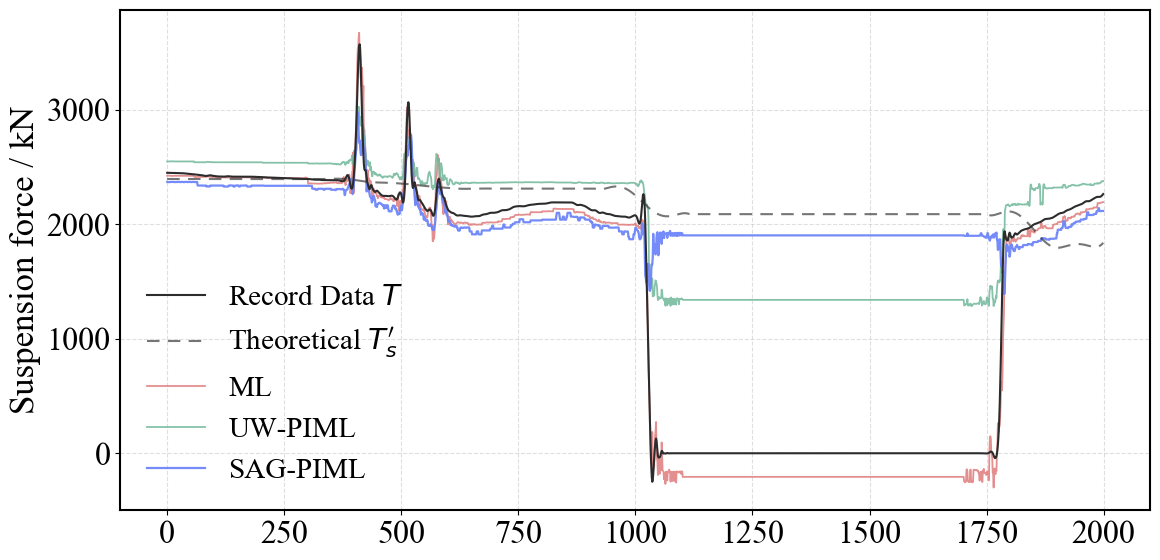

In [17]:
# ====================
# Plot B: Classic Segment Prediction (Redraw with specified k/delta)
# ====================
# Usage: After training, modify the three parameters below and run this cell to generate the plot.
# VIEW_K / VIEW_DELTA : Specify gating parameters to inspect (must exist in kdelta_preds, or set None to use main model)
# VIEW_SEG            : Specify the plot segment [start_idx, end_idx]
# ─────────────────────────────────────────────────────────────────────────────
VIEW_K     =  1  # ← set k value (e.g. 1.0), None = use main pipeline model_sag
VIEW_DELTA = 1600   # ← set delta value (e.g. 800), None = use main pipeline model_sag
VIEW_SEG   = (4000, 6000)   # ← specify plot segment
FS  = 25
# ─────────────────────────────────────────────────────────────────────────────
def _get_sag_pred_for_kdelta(k_val, delta_val):
    """
    Retrieve prediction results for the specified (k, delta) from kdelta_preds.
    If not found in kdelta_preds, temporarily train one fold and return predictions.
    """
    key = (float(k_val), float(delta_val))
    _preds = globals().get('kdelta_preds', {}).get(key)

    if _preds is not None:
        print(f"[PlotB] Retrieved k={k_val}, delta={delta_val} predictions from kdelta_preds")
        return np.array(_preds).flatten()

    # Not in cache → train one fold temporarily
    print(f"[PlotB] ({k_val}, {delta_val}) not found in kdelta_preds, training one fold temporarily...")
    _orig_k, _orig_d = huber_phy_loss.k, huber_phy_loss.delta
    huber_phy_loss.k, huber_phy_loss.delta = k_val, delta_val

    _kf   = KFold(n_splits=5, shuffle=True, random_state=21)
    _fidx = list(_kf.split(X_train_shuffled))[0]
    _Xf   = X_train_shuffled[_fidx[0]]
    _yf   = y_train_target[_fidx[0]]
    _oidx = train_orig_idx[_fidx[0]]
    huber_phy_loss.train_indices = _oidx

    _params = build_params(lambda p, d: huber_phy_loss(p, d), 'huberphy')
    _feval  = lambda p, d: custom_metric_huberphy(p, d, huber_phy_loss)
    _ptest, _, _, _ = train_and_predict(
        _Xf, X_test_ori, _yf, y_test_target,
        _params, 'huberphy', _feval,
        num_boost_round=NUM_BOOST_ROUND,
    )
    huber_phy_loss.k, huber_phy_loss.delta = _orig_k, _orig_d
    huber_phy_loss.train_indices = train_orig_idx
    return np.array(_ptest).flatten()


def fig_classic_segment(y_true_all, y_pred_ml_all, y_pred_piml_all, y_pred_sag_all,
                         theoretical_force_all,
                         start_idx=4000, end_idx=6000,
                         window_length=201, polyorder=5,
                         sag_label='SAG-PIML'):
    seg  = slice(start_idx, end_idx)
    x    = np.arange(end_idx - start_idx)
    yt   = np.array(y_true_all).flatten()
    ym   = np.array(y_pred_ml_all).flatten()
    yp   = np.array(y_pred_piml_all).flatten()
    ys   = np.array(y_pred_sag_all).flatten()
    yphy = np.array(theoretical_force_all).flatten()

    seg_len = end_idx - start_idx
    wl      = min(window_length, seg_len if seg_len % 2 == 1 else seg_len - 1)
    sphy    = savgol_filter(yphy[seg], window_length=wl, polyorder=polyorder)

    fig, ax_main = plt.subplots(figsize=(12, 6))

    ax_main.plot(x, yt[seg],  color=C_TRUE, lw=1.5, label='Record Data $T$',                        zorder=5)
    ax_main.plot(x, sphy,     color=C_TRUE, lw=1.5, ls='--', dashes=(6,4), alpha=0.65,
                 label=r'Theoretical $T_s^{\prime}$', zorder=4)
    ax_main.plot(x, ym[seg],  color=C_ML,   lw=1.3, alpha=0.85, label=f'ML')
    ax_main.plot(x, yp[seg],  color=C_PIML, lw=1.3, alpha=0.85, label='UW-PIML')
    ax_main.plot(x, ys[seg],  color=C_SAG,  lw=1.6, alpha=0.95, label=sag_label,                zorder=3)
    # ax_main.set_xlabel(f'Sample Index  [seg {start_idx}:{end_idx}]', fontsize=FS)
    ax_main.set_ylabel(r'Suspension force / kN', fontsize=FS)
    ax_main.legend(fontsize=FS-4, frameon=False, ncol=1, loc='lower left')
    ax_main.grid(True, ls='--', alpha=0.4)
    ax_main.tick_params(labelsize=FS-2)
    for sp in ax_main.spines.values(): sp.set_linewidth(1.5)

    plt.tight_layout()
# ─── Main Execution Logic ─────────────────────────────────────────────────────────
_s, _e = VIEW_SEG

if VIEW_K is None or VIEW_DELTA is None:
    # Use the model_sag trained in the main pipeline
    _sag_pred = y_pred_sag
    _label    = f'SAG-PIML'
    print(f"[PlotB] Using main pipeline model_sag  k={huber_phy_loss.k}, delta={huber_phy_loss.delta}")
else:
    _sag_pred = _get_sag_pred_for_kdelta(VIEW_K, VIEW_DELTA)
    _label    = f'SAG-PIML'

fig_classic_segment(
    y_true_flat, y_pred_ml, y_pred_piml, _sag_pred,
    theoretical_force_test,
    start_idx=_s, end_idx=_e,
    sag_label=_label,
)
plt.show()


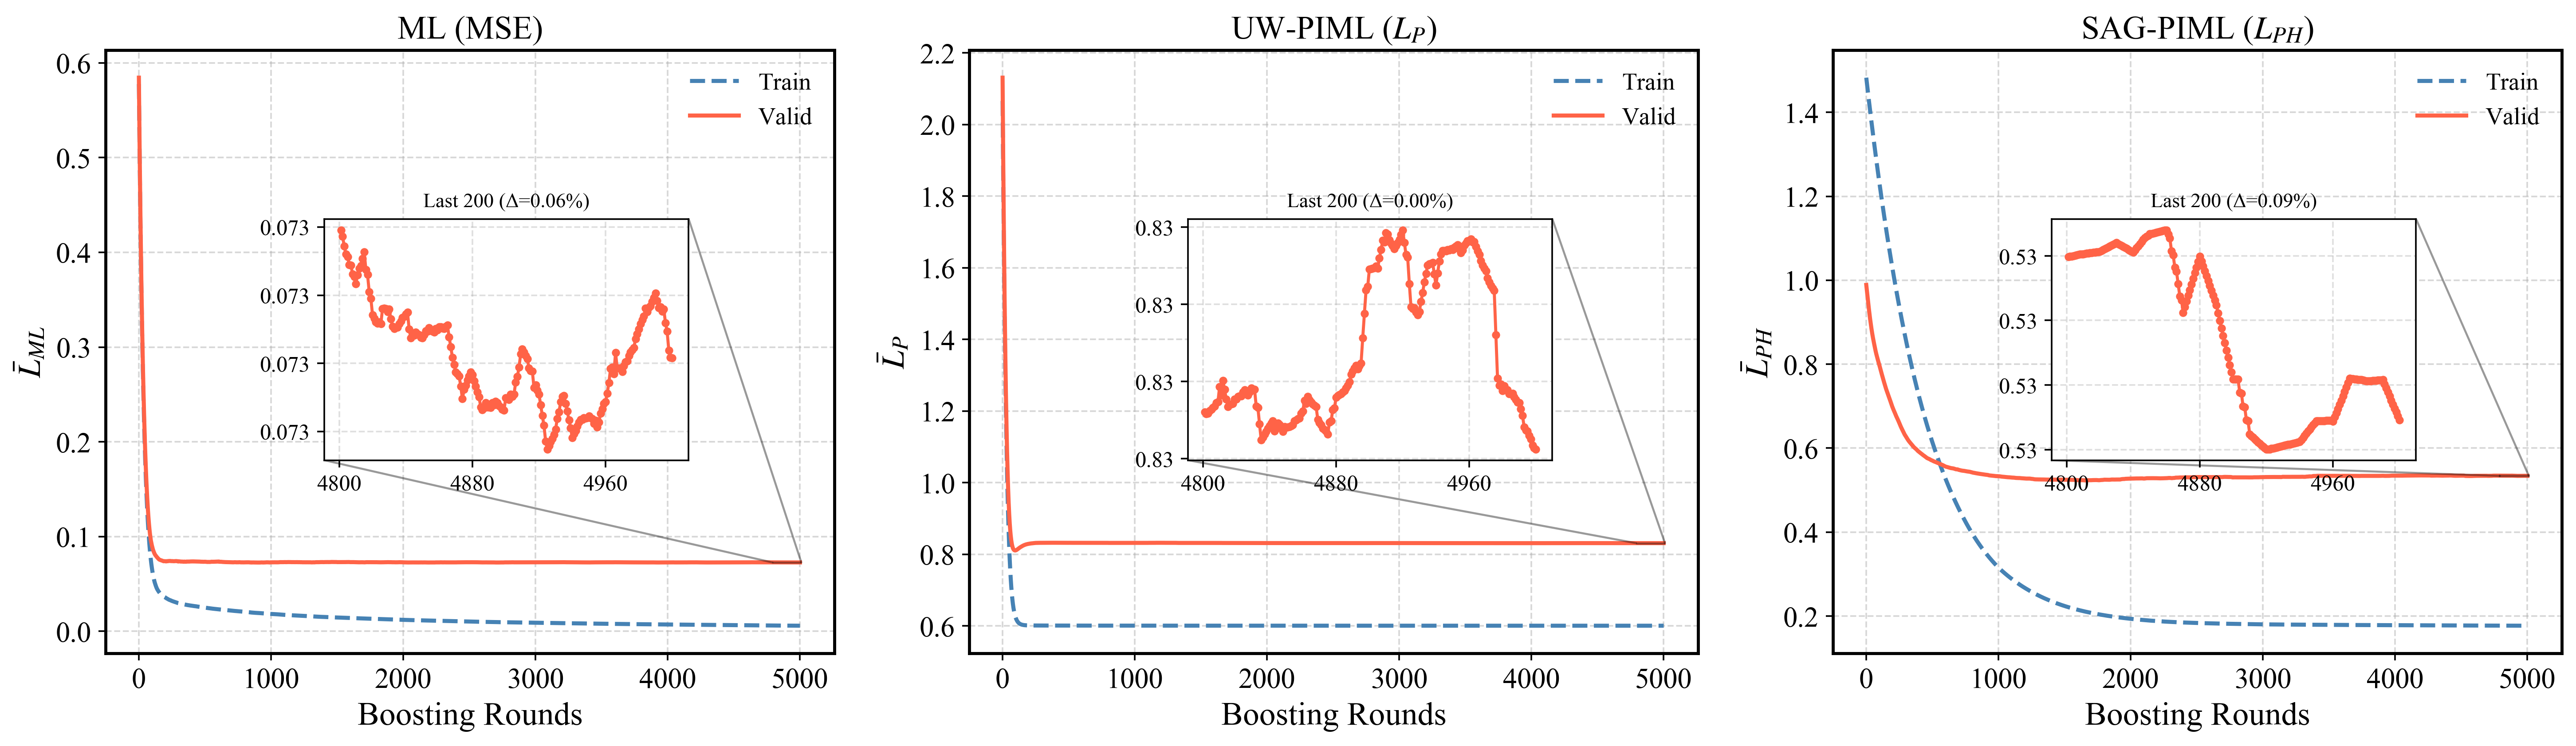

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23640\885069347.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


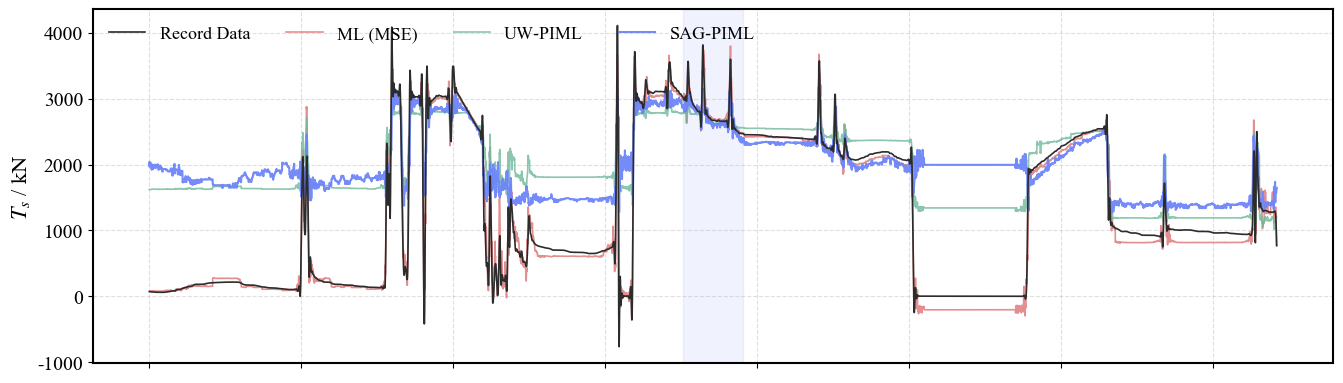

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23640\885069347.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


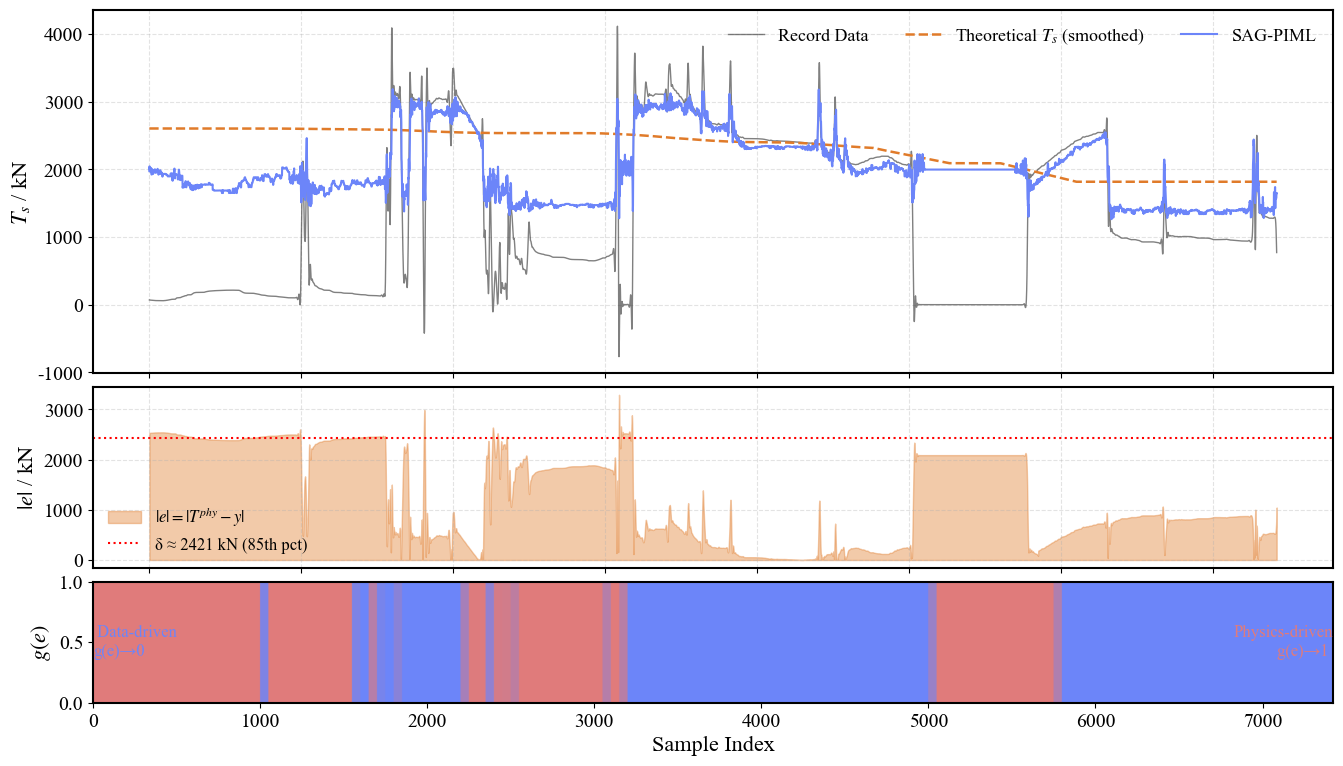

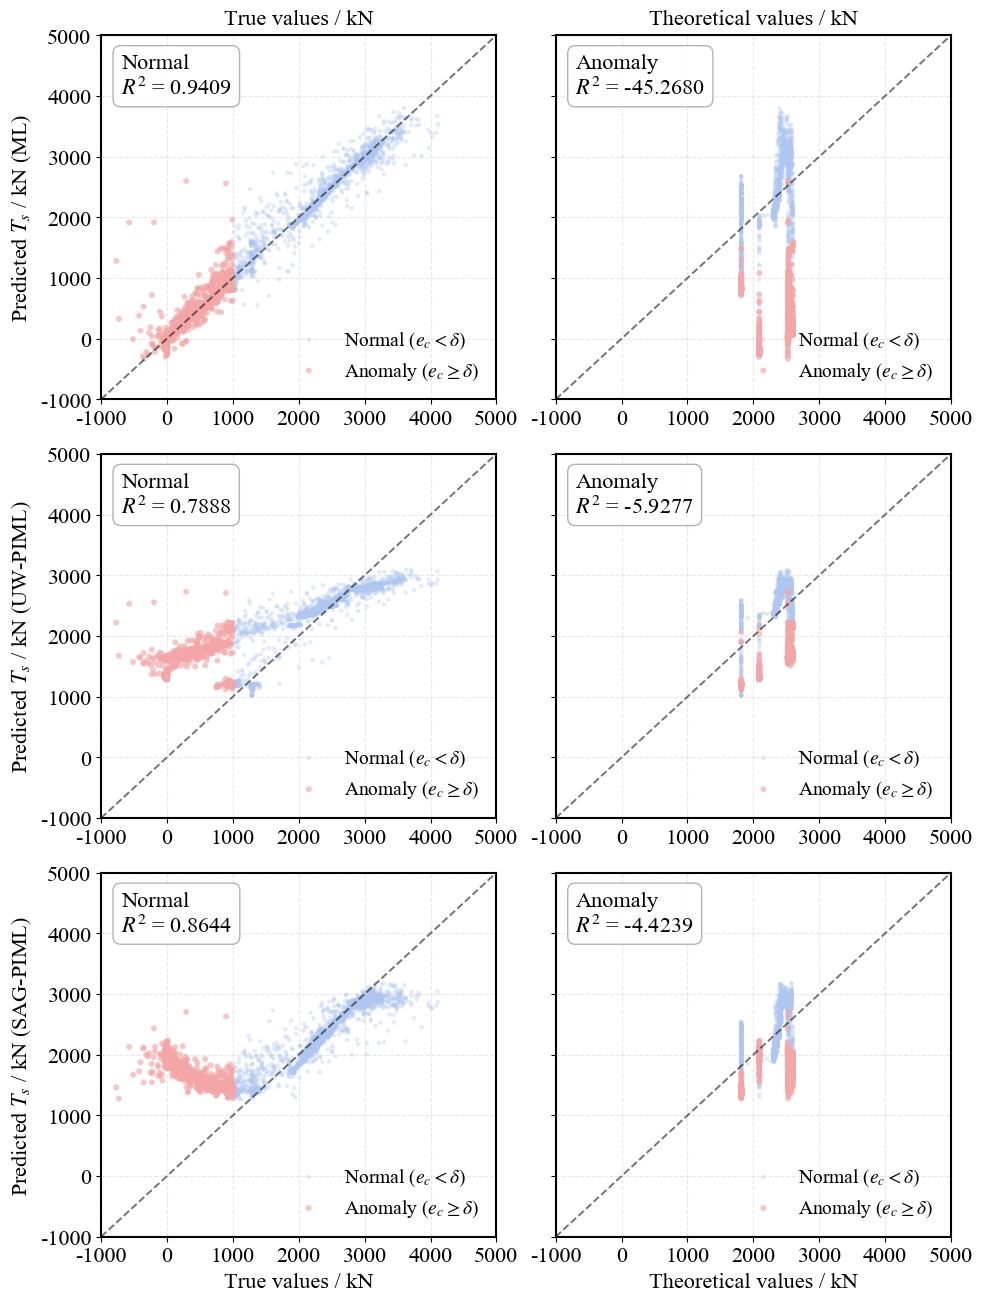

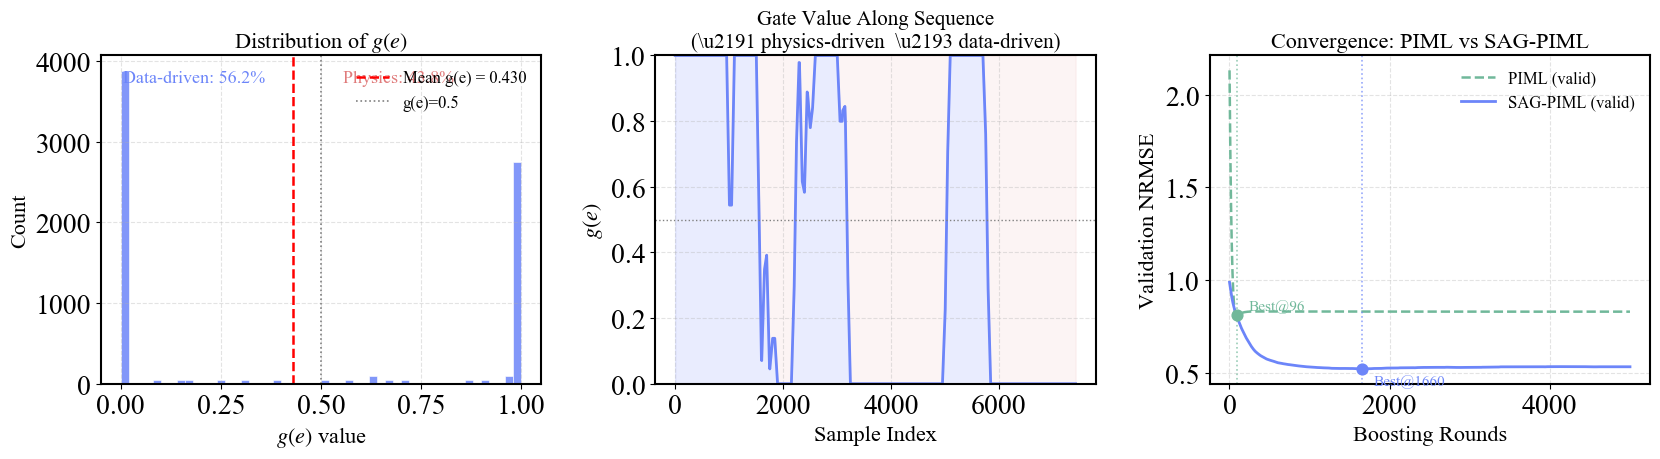

In [24]:
# ====================
# Section 16: Unified Plotting (Plot First, Then Grid Search)
# ====================
y_true_flat = y_test_ori[:len(y_pred_sag), 0]
# ── Loss Curves (revised: per-model Y-axis labels, compressed spacing)
loss_ylabel_map = {
    f'ML ({ML_LOSS_TYPE.upper()})': r'$\bar{L}_{ML}$',
    r'UW-PIML ($L_{P}$)':            r'$\bar{L}_{P}$',
    r'SAG-PIML ($L_{PH}$)':        r'$\bar{L}_{PH}$',
}
_orig_loss_data = [
    {'name': f'ML ({ML_LOSS_TYPE.upper()})',          'train': train_l_ml[0],   'valid': valid_l_ml[0]},
    {'name': r'UW-PIML ($L_{P}$)',                      'train': train_l_piml[0], 'valid': valid_l_piml[0]},
    {'name': r'SAG-PIML ($L_{PH}$)',                  'train': train_l_sag[0],  'valid': valid_l_sag[0]},
]

# Temporarily switch to Times+SimSun font
_font_prop = font_manager.FontProperties(fname='times+simsun.ttf')
plt.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : [_font_prop.get_name()],
    'mathtext.fontset': 'stix',
})
FS = 16
n_lc = len(_orig_loss_data)
fig_lc, axes_lc = plt.subplots(1, n_lc, figsize=(6*n_lc, 5.5),dpi = 330)
fig_lc.subplots_adjust(wspace=0)
recall_rounds = 200

for ax_lc, entry in zip(axes_lc, _orig_loss_data):
    name_lc  = entry['name']
    train_lc = list(entry['train'])
    valid_lc = list(entry['valid'])

    ax_lc.plot(range(1, len(train_lc)+1), train_lc, label='Train', ls='--', color='steelblue', lw=2)
    ax_lc.plot(range(1, len(valid_lc)+1), valid_lc, label='Valid',          color='tomato',    lw=2)
    ax_lc.set_title(name_lc,                                    fontsize=FS)
    ax_lc.set_xlabel('Boosting Rounds',                         fontsize=FS)
    ax_lc.set_ylabel(loss_ylabel_map.get(name_lc, 'Loss'),      fontsize=FS)
    ax_lc.legend(fontsize=FS-4, frameon=False)
    ax_lc.grid(True, ls='--', alpha=0.5)
    ax_lc.tick_params(labelsize=FS-2)
    for sp in ax_lc.spines.values(): sp.set_linewidth(1.5)

    # ── Inset convergence zoom plot ──────────────────────────────────
    ax_in2  = ax_lc.inset_axes([0.30, 0.320, 0.50, 0.40])
    actual2 = min(recall_rounds, len(valid_lc))
    x_sub2  = range(len(valid_lc)-actual2+1, len(valid_lc)+1)
    y_sub2  = valid_lc[-actual2:]
    ax_in2.plot(x_sub2, y_sub2, color='tomato', marker='o', markersize=3, lw=1.5)
    y_arr2  = np.array(y_sub2)
    delta2  = np.abs(y_arr2[-1]-y_arr2[0]) / (np.abs(y_arr2[0])+1e-10) * 100
    ax_in2.set_title(f'Last {actual2} (\u0394={delta2:.2f}%)', fontsize=FS-6)
    ax_in2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))
    ax_in2.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax_in2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2g'))
    ax_in2.grid(True, ls='--', alpha=0.4)
    ax_in2.tick_params(labelsize=FS-5)
    ax_lc.indicate_inset_zoom(ax_in2, edgecolor='black', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Fig 1: Prediction Comparison ────────────────────────────────────
fig1_prediction_overview(y_true_flat, y_pred_ml, y_pred_piml, y_pred_sag)
plt.show()

# # ── Fig 2: Noise Robustness ────────────────────────────────────────
# fig2_noise_robustness(
#     y_true_flat,
#     y_pred_ml,       y_pred_piml,       y_pred_sag,
#     y_pred_ml_noisy, y_pred_piml_noisy, y_pred_sag_noisy,
#     noise_labels=noise_labels,
# )
# plt.show()

# ── Fig 3: g(e) Gating Behavior ─────────────────────────────────────
fig3_gate_behavior(ge_df)
plt.show()

# ── Fig 4: Scatter R² ───────────────────────────────────────────────
fig4_scatter_r2(
    y_true_flat, y_pred_ml, y_pred_piml, y_pred_sag,
    ge_df=ge_df, theoretical_force=theoretical_force_test,
    threshold=1000, delta=1600,
)
plt.show()

# ── Fig 5: g(e) Distribution & Convergence Comparison ───────────────
fig5_ge_distribution_and_loss(
    ge_df,
    train_l_sag[0],  valid_l_sag[0],
    train_l_piml[0], valid_l_piml[0],
)
plt.show()

In [19]:
# ====================
# Grid Search C: k / delta Parameter Sweep + Single-Point Validation
# (Run this cell after confirming results from the unified plotting cell above)
#
# Instructions:
#   1. Modify K_GRID / DELTA_GRID below to set the grid scan range
#   2. Modify MY_K / MY_DELTA to set the parameter combination you want to validate
#   3. Run this cell to complete all training; results stored in kdelta_preds
#   4. Run the next cell to view plots
# ====================

# ── Parameter combination to validate individually (will produce a separate plot) ──
MY_K        = 1.0    # ← change here
MY_DELTA    = 1600    # ← change here

# ── Grid scan range (set a single value to skip grid) ────────────────────────────
K_GRID     = [0.1, 0.3, 0.5, 1]
DELTA_GRID = [1280, 1440, 1600, 1760, 1920]
# Ensure MY_K / MY_DELTA is in the grid (auto-appended if not)
if MY_K     not in K_GRID:     K_GRID.append(MY_K)
if MY_DELTA not in DELTA_GRID: DELTA_GRID.append(MY_DELTA)
K_GRID     = sorted(set(K_GRID))
DELTA_GRID = sorted(set(DELTA_GRID))

# ── Boosting rounds for grid search (fewer than main pipeline for quick scan) ──────
SCAN_BOOST_ROUND = 5000

k_values             = []
delta_values         = []
data_loss_values     = []
phy_loss_values_grid = []
kdelta_preds         = {}

_yphy_fixed = np.array(theoretical_force_test).flatten()[:len(y_true_flat)]
_phy_mae    = float(np.mean(np.abs(y_true_flat - _yphy_fixed)))

_orig_k     = huber_phy_loss.k
_orig_delta = huber_phy_loss.delta

print(f'Scanning {len(K_GRID)} x {len(DELTA_GRID)} = {len(K_GRID)*len(DELTA_GRID)} combinations of (k, delta) ...')
print(f'Fixed physics baseline MAE = {_phy_mae:.2f} kN')
print(f'Target single point: k={MY_K}, delta={MY_DELTA}')

for _k in K_GRID:
    for _d in DELTA_GRID:
        huber_phy_loss.k     = _k
        huber_phy_loss.delta = _d

        params_scan = build_params(lambda p, d: huber_phy_loss(p, d), 'huberphy')

        _kf = KFold(n_splits=5, shuffle=True, random_state=21)
        _fold_idx      = list(_kf.split(X_train_shuffled))[0]
        _X_fold        = X_train_shuffled[_fold_idx[0]]
        _y_fold        = y_train_target[_fold_idx[0]]
        _orig_idx_fold = train_orig_idx[_fold_idx[0]]
        huber_phy_loss.train_indices = _orig_idx_fold

        _feval_scan = lambda p, d: custom_metric_huberphy(p, d, huber_phy_loss)
        _preds_test, _, _m, _ = train_and_predict(
            _X_fold, X_test_ori, _y_fold, y_test_target,
            params_scan, 'huberphy', _feval_scan,
            num_boost_round=SCAN_BOOST_ROUND,   # quick scan, full rounds not needed
        )

        _data_mae = float(np.mean(np.abs(y_true_flat - _preds_test[:len(y_true_flat)])))
        _phy_mae_kd = float(np.mean(np.abs(_preds_test[:len(y_true_flat)] - _yphy_fixed)))  # predicted value - theoretical force
        k_values.append(_k)
        delta_values.append(_d)
        data_loss_values.append(_data_mae)
        phy_loss_values_grid.append(_phy_mae_kd)
        kdelta_preds[(_k, _d)] = _preds_test.copy()
        print(f'  k={_k:.1f}  delta={_d:5.0f}  MAE={_data_mae:.2f} kN'
              + (' ← YOUR POINT' if _k == MY_K and _d == MY_DELTA else ''))

# Restore main pipeline parameters
huber_phy_loss.k             = _orig_k
huber_phy_loss.delta         = _orig_delta
huber_phy_loss.train_indices = train_orig_idx

k_values             = np.array(k_values,             dtype=float)
delta_values         = np.array(delta_values,         dtype=float)
data_loss_values     = np.array(data_loss_values,     dtype=float)
phy_loss_values_grid = np.array(phy_loss_values_grid, dtype=float)

_best_idx   = int(np.argmin(data_loss_values))
_best_k     = float(k_values[_best_idx])
_best_delta = float(delta_values[_best_idx])
_my_mae = data_loss_values[(k_values == MY_K) & (delta_values == MY_DELTA)][0]
print(f'Grid best: k={_best_k}, delta={_best_delta}, MAE={data_loss_values[_best_idx]:.2f} kN')
print(f'Your setting: k={MY_K},    delta={MY_DELTA},    MAE={_my_mae:.2f} kN')


Scanning 4 x 5 = 20 combinations of (k, delta) ...
Fixed physics baseline MAE = 1236.53 kN
Target single point: k=1.0, delta=1600


  └─ best_val=0.4924
  └─ best_round=850/5000
  k=0.1  delta= 1280  MAE=796.95 kN


  └─ best_val=0.4943
  └─ best_round=1920/5000
  k=0.1  delta= 1440  MAE=711.53 kN


  └─ best_val=0.4382
  └─ best_round=1920/5000
  k=0.1  delta= 1600  MAE=624.65 kN


  └─ best_val=0.3970
  └─ best_round=2510/5000
  k=0.1  delta= 1760  MAE=560.62 kN


...

  └─ best_val=0.2939
  └─ best_round=589/5000
  k=1.0  delta= 1280  MAE=890.21 kN


  └─ best_val=0.5605
  └─ best_round=657/5000
  k=1.0  delta= 1440  MAE=835.47 kN


  └─ best_val=0.5232
  └─ best_round=1660/5000
  k=1.0  delta= 1600  MAE=763.32 kN ← YOUR POINT


  └─ best_val=0.4747
  └─ best_round=1660/5000
  k=1.0  delta= 1760  MAE=659.75 kN


  └─ best_val=0.4240
  └─ best_round=1890/5000
  k=1.0  delta= 1920  MAE=607.69 kN
Grid best: k=0.1, delta=1920.0, MAE=448.19 kN
Your setting: k=1.0,    delta=1600,    MAE=763.32 kN


In [20]:
# ── Supplement single point delta=2080 ──────────────────────────────
_extra_deltas = [2080]
_extra_ks     = K_GRID  # reuse the existing k grid, or specify separately e.g. [0.5, 1.0]

for _k in _extra_ks:
    for _d in _extra_deltas:
        if any((k_values == _k) & (delta_values == _d)):
            print(f'  Already exists k={_k}, delta={_d}, skipping')
            continue

        huber_phy_loss.k     = _k
        huber_phy_loss.delta = _d

        params_scan = build_params(lambda p, d: huber_phy_loss(p, d), 'huberphy')

        _kf = KFold(n_splits=5, shuffle=True, random_state=21)
        _fold_idx      = list(_kf.split(X_train_shuffled))[0]
        _X_fold        = X_train_shuffled[_fold_idx[0]]
        _y_fold        = y_train_target[_fold_idx[0]]
        _orig_idx_fold = train_orig_idx[_fold_idx[0]]
        huber_phy_loss.train_indices = _orig_idx_fold

        _feval_scan = lambda p, d: custom_metric_huberphy(p, d, huber_phy_loss)
        _preds_test, _, _m, _ = train_and_predict(
            _X_fold, X_test_ori, _y_fold, y_test_target,
            params_scan, 'huberphy', _feval_scan,
            num_boost_round=SCAN_BOOST_ROUND,
        )

        _data_mae   = float(np.mean(np.abs(y_true_flat - _preds_test[:len(y_true_flat)])))
        _phy_mae_kd = float(np.mean(np.abs(_preds_test[:len(y_true_flat)] - _yphy_fixed)))

        k_values             = np.append(k_values,             _k)
        delta_values         = np.append(delta_values,         _d)
        data_loss_values     = np.append(data_loss_values,     _data_mae)
        phy_loss_values_grid = np.append(phy_loss_values_grid, _phy_mae_kd)
        kdelta_preds[(_k, _d)] = _preds_test.copy()
        print(f'  k={_k:.1f}  delta={_d:5.0f}  MAE={_data_mae:.2f} kN  ← new')

# Restore main pipeline parameters
huber_phy_loss.k             = _orig_k
huber_phy_loss.delta         = _orig_delta
huber_phy_loss.train_indices = train_orig_idx

  └─ best_val=0.2498
  └─ best_round=2090/5000
  k=0.1  delta= 2080  MAE=352.05 kN  ← new


  └─ best_val=0.3494
  └─ best_round=1960/5000
  k=0.3  delta= 2080  MAE=489.80 kN  ← new


  └─ best_val=0.3719
  └─ best_round=1960/5000
  k=0.5  delta= 2080  MAE=521.29 kN  ← new


  └─ best_val=0.3846
  └─ best_round=2010/5000
  k=1.0  delta= 2080  MAE=543.33 kN  ← new


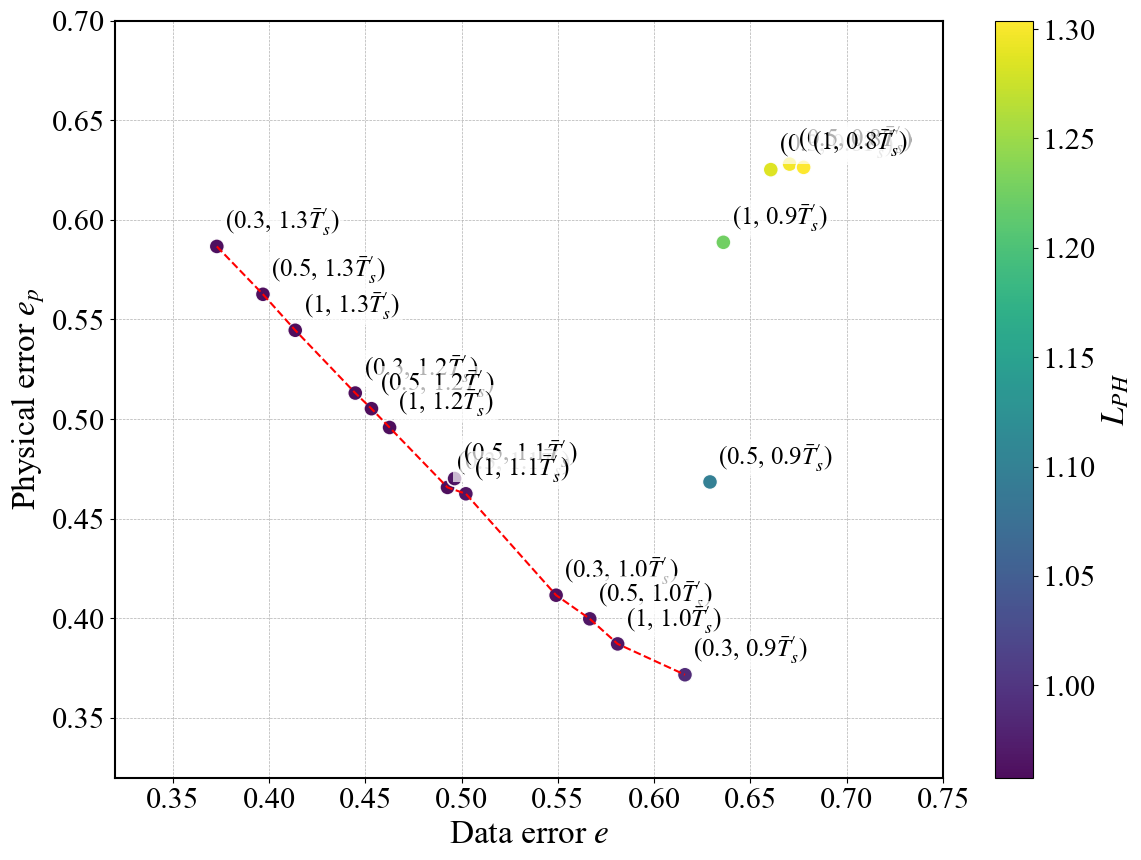

In [21]:
# ====================
# Plot D: k/delta Sensitivity Analysis
# ====================
FS = 24
_PLOT_THRESHOLD = 1000
_PLOT_DELTA     = 1200
_yphy  = np.array(theoretical_force_test).flatten()[:len(y_true_flat)]
_y_mean = float(np.mean(np.abs(y_true_flat))) + 1e-8

# Normalize
norm_data_loss_all     = np.array(data_loss_values)     / _y_mean
norm_phy_loss_all      = np.array(phy_loss_values_grid) / _y_mean
combined_loss_grid_all = norm_phy_loss_all + norm_data_loss_all
k_values_arr           = np.array(k_values)
delta_values_arr       = np.array(delta_values)

# Filter (modify here to control which points are displayed)
# DELTA_GRID = [1280, 1440, 1600, 1760, 1920]
_valid             = (k_values_arr != 0.1) & (delta_values_arr != 0) & (delta_values_arr != 0) & (delta_values_arr != 0)
norm_data_loss     = norm_data_loss_all[_valid]
norm_phy_loss      = norm_phy_loss_all[_valid]
combined_loss_grid = combined_loss_grid_all[_valid]
k_plot             = k_values_arr[_valid]
delta_plot         = delta_values_arr[_valid]

# ── Fig 1: Pareto Front ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 9),)
scatter = ax1.scatter(
    norm_data_loss, norm_phy_loss,
    c=combined_loss_grid, cmap='viridis',
    s=120, edgecolor='white', linewidths=1.2,
    alpha=0.95, zorder=3,
)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label(r'$L_{PH}$', fontsize=FS)
cbar.ax.tick_params(labelsize=FS-2)

# Pareto front
_pts        = np.array([norm_data_loss, norm_phy_loss]).T
_sorted_idx = np.argsort(_pts[:, 0])
_sorted_pts = _pts[_sorted_idx]
pareto_idx  = [_sorted_idx[0]]
_cur_pareto = _sorted_pts[0]
for _ii in range(1, len(_sorted_pts)):
    if _sorted_pts[_ii][1] < _cur_pareto[1]:
        pareto_idx.append(_sorted_idx[_ii])
        _cur_pareto = _sorted_pts[_ii]

pareto_data = [norm_data_loss[_i] for _i in pareto_idx]
pareto_phy  = [norm_phy_loss[_i]  for _i in pareto_idx]
ax1.plot(pareto_data, pareto_phy,
         color='red', linestyle='--', linewidth=1.5, label='Pareto Front', zorder=4)

# ── Label each point ───────────────────────────────────────────────
for _i in range(len(norm_phy_loss)):
    _kv  = k_plot[_i]
    _dv  = delta_plot[_i]
    _px  = norm_data_loss[_i]
    _py  = norm_phy_loss[_i]
    _lbl = rf'({_kv:g}, {_dv/1600:.1f}$\bar{{T}}_s^\prime$)'
    ax1.annotate(
        _lbl,
        xy=(_px, _py),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=FS - 6,
        ha='left', va='bottom',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2),
        zorder=5,
    )

ax1.set_xlabel(r'Data error $e$',   fontsize=FS)
ax1.set_ylabel(r'Physical error $e_p$', fontsize=FS)
ax1.tick_params(labelsize=FS-2)
# ax1.legend(frameon=False, fontsize=FS-4)
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.set_ylim(0.32, 0.7)
ax1.set_xlim(0.32, 0.75)
for sp in ax1.spines.values(): sp.set_linewidth(1.5)
plt.tight_layout(); plt.show()

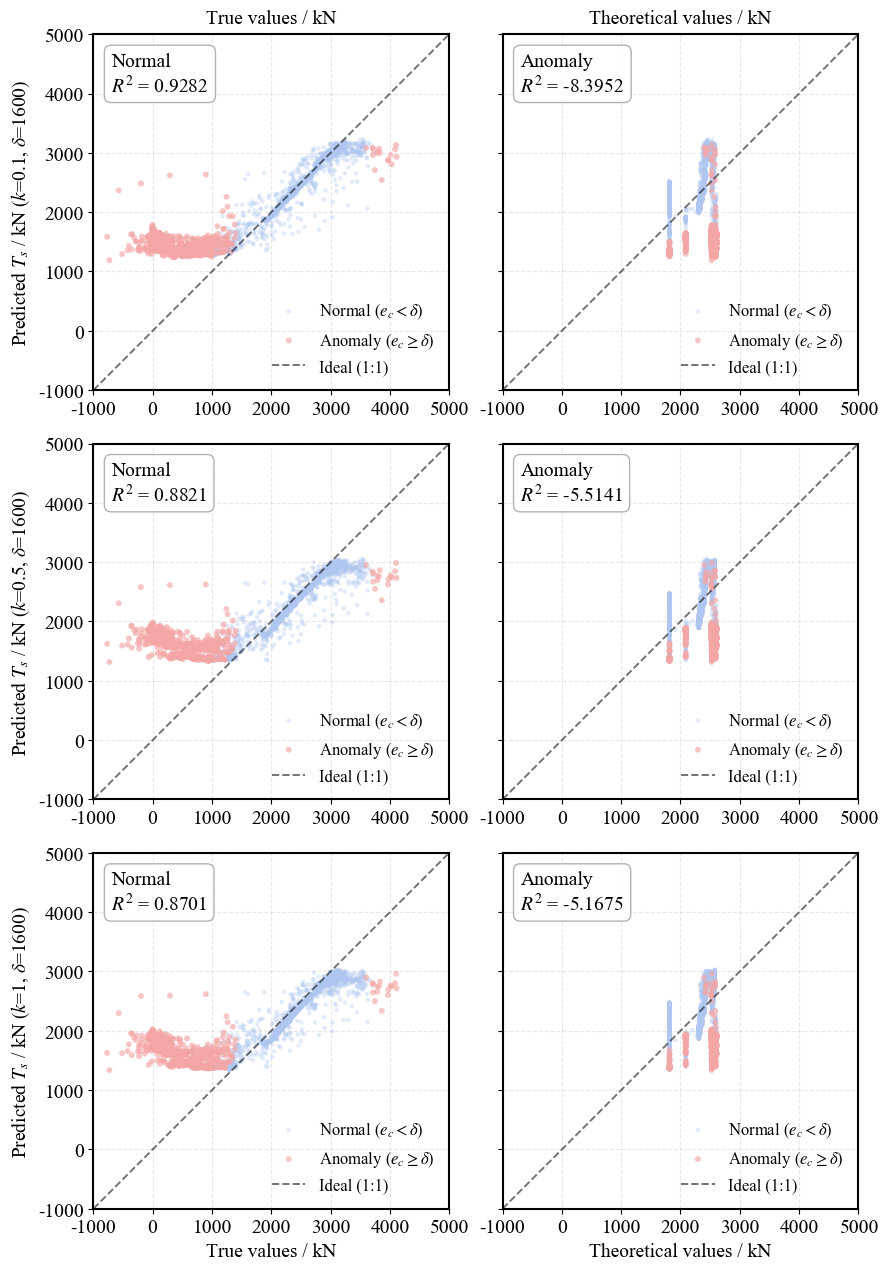

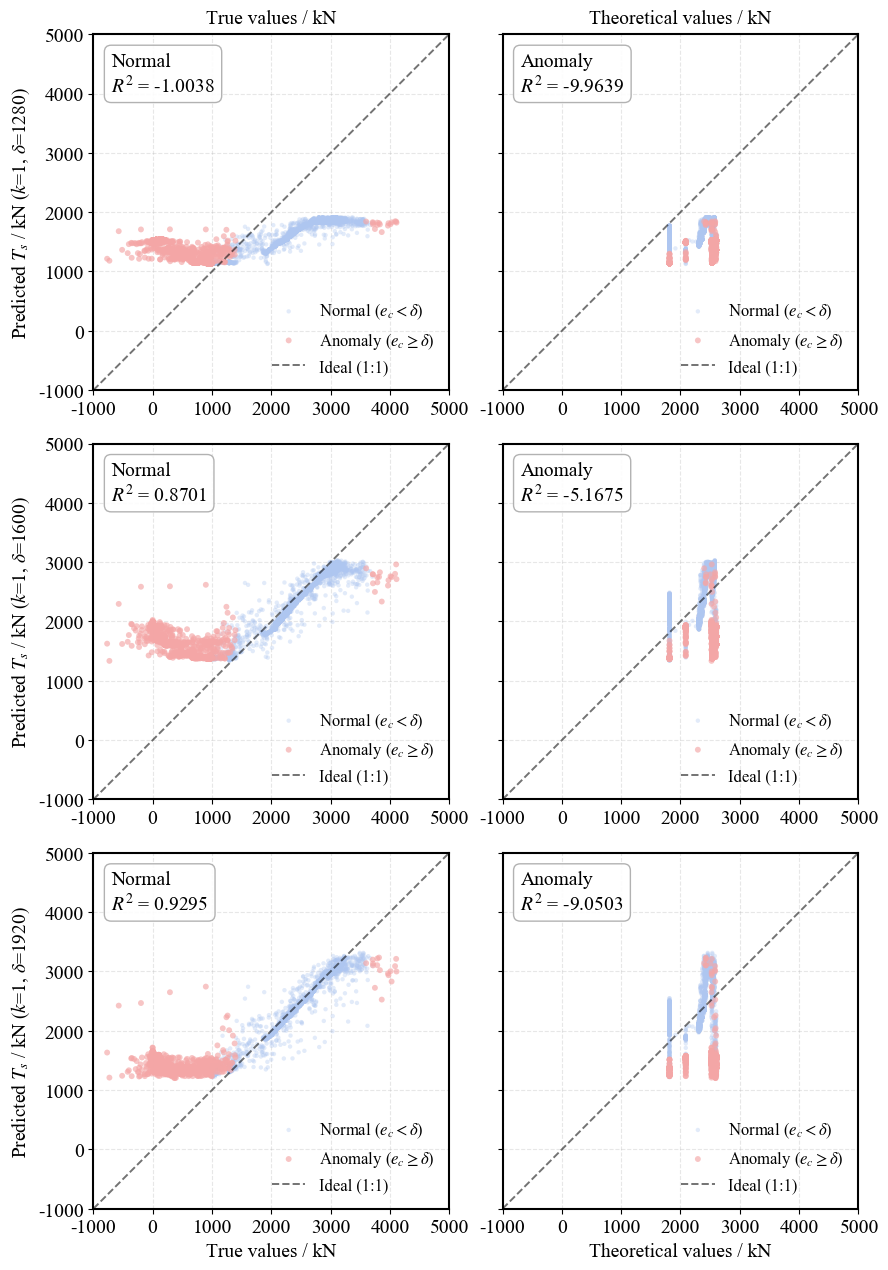

In [22]:
# ══════════════════════════════════════════════════════
# Plot D Fig4/Fig5: k/delta Sensitivity Scatter R² Comparison
# ── Parameter Tuning Zone ──────────────────────────────
SCAN_FIXED_K     = 1.0
SCAN_FIXED_DELTA = 1600.0
FIG_W            = 9
FIG_ROW_H        = 4.5
HSPACE           = 0.15
WSPACE           = 0.15
LEFT, RIGHT      = 0.12, 0.97
TOP,  BOTTOM     = 0.95, 0.08
FS               = 14

# ── Manually specify (k, delta) combinations to display ─
# None = auto-scan all with SCAN_FIXED_K / SCAN_FIXED_DELTA
# Example: [(0.5, 1600), (1.0, 1600), (1.0, 2080)]
SELECT_FIG4 = [(0.1, 1600), (0.5, 1600), (1, 1600)]
SELECT_FIG5 = [(1, 1280), (1, 1600), (1, 1920)]
# ══════════════════════════════════════════════════════

_C_NORM = '#AEC6F0'; _C_ANOM = '#F4A6A6'
_LIMS   = [-1000, 5000]
mask_anom_d = (y_true_flat < _PLOT_THRESHOLD) | (np.abs(y_true_flat - _yphy) > _PLOT_DELTA)
mask_norm_d = ~mask_anom_d
_x_rows  = [y_true_flat, _yphy]
_xlabels = [r'True values / kN', r'Theoretical values / kN']
_fm_list = [mask_norm_d, mask_anom_d]


def _scatter_r2_grid(fig, axes, pred_list, param_labels):
    n_rows = len(pred_list)
    for row, (pred, plabel) in enumerate(zip(pred_list, param_labels)):
        for col, (x_all, xlabel, fm) in enumerate(zip(_x_rows, _xlabels, _fm_list)):
            ax = axes[row, col]

            if row == 0:
                ax.set_title(xlabel, fontsize=FS, pad=8)

            ax.scatter(x_all[mask_norm_d], pred[mask_norm_d],
                       c=_C_NORM, s=10, alpha=0.35, edgecolors='none',
                       label=r'Normal ($e_c < \delta$)', zorder=2, rasterized=True)
            ax.scatter(x_all[mask_anom_d], pred[mask_anom_d],
                       c=_C_ANOM, s=18, alpha=0.65, edgecolors='none',
                       label=r'Anomaly ($e_c \geq \delta$)', zorder=3, rasterized=True)
            ax.plot(_LIMS, _LIMS, 'k--', lw=1.4, alpha=0.55, zorder=4, label='Ideal (1:1)')

            if fm.sum() > 1:
                if col == 0:
                    r2_val  = r2_score(y_true_flat[mask_norm_d], pred[mask_norm_d])
                    lbl_str = 'Normal'
                else:
                    r2_val  = r2_score(_yphy[mask_anom_d], pred[mask_anom_d])
                    lbl_str = 'Anomaly'
                ax.text(0.05, 0.95,
                        f'{lbl_str}\n$R^2$ = {r2_val:.4f}',
                        transform=ax.transAxes, fontsize=FS, va='top',
                        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                                  edgecolor='#aaaaaa', alpha=0.9))

            ax.set_xlim(_LIMS)
            ax.set_ylim(_LIMS)
            ax.xaxis.set_major_locator(MultipleLocator(1000))
            ax.yaxis.set_major_locator(MultipleLocator(1000))

            ax.tick_params(axis='x', which='both', labelsize=FS, bottom=True, labelbottom=True)
            ax.tick_params(axis='y', which='both', labelsize=FS, left=True, labelleft=(col == 0))

            if row == n_rows - 1:
                ax.set_xlabel(xlabel, fontsize=FS)
            if col == 0:
                ax.set_ylabel(f'Predicted $T_s$ / kN ({plabel})', fontsize=FS)

            ax.legend(fontsize=FS-2, frameon=False, loc='lower right')
            ax.grid(True, ls='--', alpha=0.3)
            for sp in ax.spines.values(): sp.set_linewidth(1.5)

    fig.subplots_adjust(hspace=HSPACE, wspace=WSPACE,
                        left=LEFT, right=RIGHT,
                        top=TOP,   bottom=BOTTOM)


# ── Fig 4: Fixed k, sweep delta ─────────────────────────────────────
if SELECT_FIG4 is not None:
    _pairs4  = SELECT_FIG4
else:
    _d_list4 = sorted(set(delta_values[k_values == SCAN_FIXED_K]))
    _pairs4  = [(SCAN_FIXED_K, d) for d in _d_list4]

_pred4   = [np.array(kdelta_preds[(k, d)]).flatten()[:len(y_true_flat)] for k, d in _pairs4]
_labels4 = [rf'$k$={k:g}, $\delta$={d:.0f}' for k, d in _pairs4]

fig4, axes4 = plt.subplots(len(_pairs4), 2, figsize=(FIG_W, FIG_ROW_H * len(_pairs4)))
_scatter_r2_grid(fig4, axes4, _pred4, _labels4)
plt.show()


# ── Fig 5: Fixed delta, sweep k ─────────────────────────────────────
if SELECT_FIG5 is not None:
    _pairs5  = SELECT_FIG5
else:
    _k_list5 = sorted(set(k_values[delta_values == SCAN_FIXED_DELTA]))
    _pairs5  = [(k, SCAN_FIXED_DELTA) for k in _k_list5]

_pred5   = [np.array(kdelta_preds[(k, d)]).flatten()[:len(y_true_flat)] for k, d in _pairs5]
_labels5 = [rf'$k$={k:g}, $\delta$={d:.0f}' for k, d in _pairs5]

fig5, axes5 = plt.subplots(len(_pairs5), 2, figsize=(FIG_W, FIG_ROW_H * len(_pairs5)))
_scatter_r2_grid(fig5, axes5, _pred5, _labels5)
plt.show()